<a href="https://colab.research.google.com/github/Asuskf/from-nlp-to-agents/blob/main/final_%20exercise/RAG_HNSW_LangGraph_LangSmith_EJECUTADO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔎 RAG de extremo a extremo, capa por capa
### con **HNSW** (hnswlib) · **LangGraph** · **LangSmith** · **OpenRouter**

---

Este cuaderno es un **taller didáctico completo**. No es un `pip install` + tres líneas: aquí
desarmamos un sistema RAG (*Retrieval-Augmented Generation*) en **todas sus capas**, explicamos
la teoría de cada una, la implementamos, la **medimos** y finalmente la orquestamos como un
**grafo de estados con LangGraph**, instrumentado con **LangSmith**.

### 🧭 Mapa del cuaderno

| # | Capa | Qué aprendes | Herramienta |
|---|------|--------------|-------------|
| 0 | Preparación | Dependencias, claves, modo offline | `pip`, `os.environ` |
| 1 | **Ingesta** | Cargar, limpiar y normalizar documentos | Python puro |
| 2 | **Chunking** | Partir texto sin romper el significado | Python puro |
| 3 | **Embeddings** | Texto → vectores; por qué normalizar a norma 1 | `sentence-transformers` (con *fallback* offline) |
| 4 | **Indexación HNSW** | Grafos navegables de mundo pequeño, `M`, `ef_construction` | `hnswlib` |
| 5 | **Recuperación** | kNN, `ef_search`, *recall* vs latencia, MMR, filtros | `hnswlib` + NumPy |
| 6 | **Búsqueda híbrida + reranking** | BM25, fusión RRF, *cross-encoder* | `rank_bm25` |
| 7 | **Generación** | Prompt con contexto, citas, anti-alucinación | **OpenRouter** |
| 8 | **Orquestación** | Estado, nodos, aristas condicionales, ciclos | **LangGraph** |
| 9 | **Observabilidad** | Trazas anidadas de cada capa | **LangSmith** |
| 10 | **Evaluación** | Recall@k, MRR, nDCG, *groundedness* con LLM-as-judge | LangSmith `evaluate` |
| 11 | Cierre | Ejercicios propuestos | — |

> 💡 **Cómo usarlo:** ejecuta las celdas en orden. El cuaderno está diseñado para funcionar
> **incluso sin conexión ni claves de API** (usa un *backend* de embeddings local y un generador
> extractivo). Si defines `OPENROUTER_API_KEY` y `LANGSMITH_API_KEY`, se activan automáticamente
> la generación real con un LLM y el trazado en LangSmith.

---
## 0 · Preparación del entorno

### 0.1 Dependencias

Ejecuta la siguiente celda **una sola vez**. Si ya tienes el entorno montado, sáltatela.

In [ ]:
# Instalación (descomenta la primera vez)
# !pip install -q hnswlib sentence-transformers rank_bm25 langgraph langsmith langchain-core openai matplotlib numpy scikit-learn

import importlib

REQUERIDOS = {
    "numpy":                 "numpy",
    "matplotlib":            "matplotlib",
    "sklearn":               "scikit-learn",
    "hnswlib":               "hnswlib",
    "rank_bm25":             "rank_bm25",
    "langgraph":             "langgraph",
    "langsmith":             "langsmith",
    "sentence_transformers": "sentence-transformers",  # opcional
    "openai":                "openai",                 # opcional (cliente de OpenRouter)
}

print("Estado de dependencias:\n")
DISPONIBLE = {}
for modulo, paquete in REQUERIDOS.items():
    try:
        importlib.import_module(modulo)
        DISPONIBLE[modulo] = True
        print(f"  ✅ {paquete:<24} disponible")
    except Exception:
        DISPONIBLE[modulo] = False
        print(f"  ⚠️  {paquete:<24} NO disponible  ->  pip install {paquete}")

Estado de dependencias:

  ✅ numpy                    disponible
  ✅ matplotlib               disponible


  ✅ scikit-learn             disponible
  ✅ hnswlib                  disponible
  ✅ rank_bm25                disponible
  ✅ langgraph                disponible
  ✅ langsmith                disponible


  ✅ sentence-transformers    disponible
  ⚠️  openai                   NO disponible  ->  pip install openai


### 0.2 Claves de API (opcionales)

| Variable | Para qué sirve | Dónde conseguirla |
|---|---|---|
| `OPENROUTER_API_KEY` | Capa de **generación** (acceso a decenas de LLM con una sola clave) | https://openrouter.ai/keys |
| `LANGSMITH_API_KEY` | Capa de **observabilidad y evaluación** | https://smith.langchain.com |

Si no las defines, el cuaderno sigue funcionando en **modo didáctico offline**:

* la generación usa un *fallback* extractivo (te muestra el prompt exacto que se habría enviado),
* el trazado usa un decorador `@traceable` inerte que no envía nada a la nube.

In [ ]:
import os, getpass

def pedir_clave(nombre, obligatoria=False):
    """Pide una clave por teclado sólo si no está ya en el entorno. Enter = omitir."""
    if os.environ.get(nombre):
        print(f"  ✅ {nombre} ya está definida en el entorno")
        return True
    try:
        valor = getpass.getpass(f"  {nombre} (Enter para omitir): ").strip()
    except Exception:
        valor = ""   # entorno no interactivo (p. ej. ejecución automatizada)
    if valor:
        os.environ[nombre] = valor
        print(f"  ✅ {nombre} definida")
        return True
    print(f"  ⏭️  {nombre} omitida  ->  se usará el modo offline")
    return False

# --- OpenRouter -------------------------------------------------------------
HAY_OPENROUTER = pedir_clave("OPENROUTER_API_KEY")

# Modelo por defecto. Consulta el catálogo en https://openrouter.ai/models
# Alternativas: "openai/gpt-4o-mini", "google/gemini-2.0-flash-001",
#               "meta-llama/llama-3.3-70b-instruct", "mistralai/mistral-small"
MODELO_OPENROUTER = os.environ.get("OPENROUTER_MODEL", "anthropic/claude-3.5-haiku")

# --- LangSmith --------------------------------------------------------------
HAY_LANGSMITH = pedir_clave("LANGSMITH_API_KEY")
if HAY_LANGSMITH:
    os.environ["LANGSMITH_TRACING"]  = "true"
    os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
    os.environ["LANGSMITH_PROJECT"]  = "rag-hnsw-educativo"
else:
    os.environ["LANGSMITH_TRACING"]  = "false"

print(f"\n  🤖 Modelo de generación: {MODELO_OPENROUTER}")
print(f"  📊 Trazado LangSmith:    {'ACTIVADO' if HAY_LANGSMITH else 'desactivado (modo offline)'}")

  ⏭️  OPENROUTER_API_KEY omitida  ->  se usará el modo offline
  ⏭️  LANGSMITH_API_KEY omitida  ->  se usará el modo offline

  🤖 Modelo de generación: anthropic/claude-3.5-haiku
  📊 Trazado LangSmith:    desactivado (modo offline)


### 0.3 El decorador `@traceable`: una sola línea para ver por dentro tu RAG

LangSmith funciona envolviendo funciones. Cada función decorada con `@traceable` se convierte en
un **span** dentro de una traza jerárquica: verás el tiempo, las entradas y las salidas de *cada capa*.

Definimos aquí un envoltorio seguro para que el cuaderno no se rompa si LangSmith no está instalado.

In [ ]:
try:
    from langsmith import traceable as _traceable
    from langsmith import Client as LangSmithClient
    _LS_OK = True
except Exception:
    _LS_OK = False

def traceable(*d_args, **d_kwargs):
    """
    Decorador compatible con langsmith.traceable.
    Si LangSmith no está disponible o el trazado está apagado, devuelve la función intacta.
    Uso:  @traceable(name="mi_capa", run_type="chain")
    """
    activo = _LS_OK and os.environ.get("LANGSMITH_TRACING") == "true"
    if activo:
        return _traceable(*d_args, **d_kwargs)
    def _decorador(func):
        return func
    # Permite usarlo tanto como @traceable  como  @traceable(...)
    if len(d_args) == 1 and callable(d_args[0]) and not d_kwargs:
        return d_args[0]
    return _decorador

print("traceable listo ->", "modo LangSmith REAL" if (_LS_OK and os.environ.get('LANGSMITH_TRACING')=='true') else "modo inerte (no-op)")

traceable listo -> modo inerte (no-op)


In [ ]:
# Imports comunes y configuración de gráficos
import numpy as np, time, textwrap, math, json, re
from dataclasses import dataclass, field
from typing import List, Dict, Any, Tuple, Optional

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
PALETA = ["#3B6EA8", "#D08C3F", "#4F9D69", "#B5524F", "#7A5EA6", "#5D8AA8"]
rng = np.random.default_rng(42)
print("Entorno numérico listo ·", np.__version__)

Entorno numérico listo · 2.4.4


### 0.4 La foto completa 🖼️

Antes de programar, veamos el sistema entero. Un RAG tiene **dos tiempos** muy distintos:

* **Indexación (offline)** — ocurre una vez, o cada vez que cambian los documentos.
* **Consulta (online)** — ocurre en cada pregunta del usuario, y debe ser *rápida*.

El índice HNSW es el puente entre ambos.

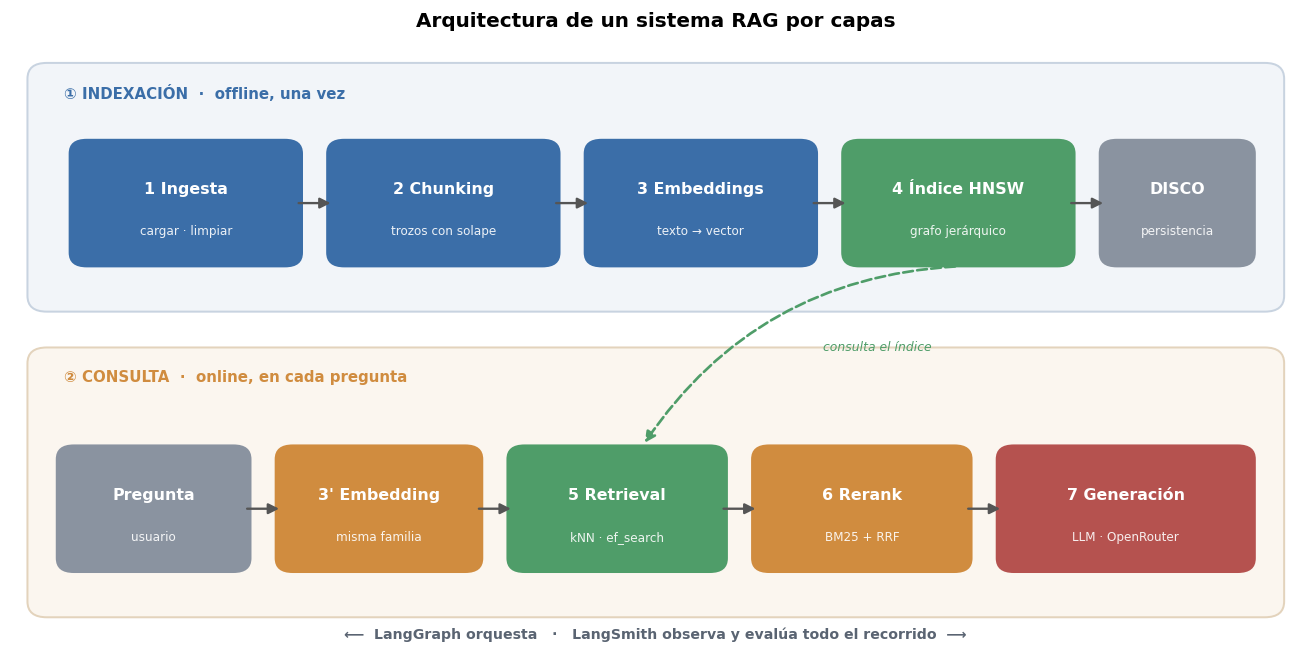

In [ ]:
def diagrama_arquitectura():
    fig, ax = plt.subplots(figsize=(11, 5.6))
    ax.set_xlim(0, 100); ax.set_ylim(0, 58); ax.axis("off"); ax.grid(False)

    def caja(x, y, w, h, titulo, sub, color, tc="white"):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.6,rounding_size=1.4",
                                    fc=color, ec="none"))
        ax.text(x + w/2, y + h*0.62, titulo, ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=tc)
        ax.text(x + w/2, y + h*0.26, sub, ha="center", va="center", fontsize=7.2, color=tc, alpha=0.9)

    def flecha(x1, y1, x2, y2, color="#555", estilo="-|>"):
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=estilo,
                                     mutation_scale=13, lw=1.4, color=color,
                                     connectionstyle="arc3,rad=0"))

    # --- Carril de indexación (offline) ---
    ax.add_patch(FancyBboxPatch((2, 33), 96, 22, boxstyle="round,pad=0.8,rounding_size=1.5",
                                fc="#F2F5F9", ec="#C8D3E0", lw=1.2))
    ax.text(4, 52.4, "① INDEXACIÓN  ·  offline, una vez", fontsize=9, fontweight="bold", color="#3B6EA8")

    caja( 5, 37, 17, 11, "1 Ingesta",      "cargar · limpiar",      PALETA[0])
    caja(25, 37, 17, 11, "2 Chunking",     "trozos con solape",     PALETA[0])
    caja(45, 37, 17, 11, "3 Embeddings",   "texto → vector",        PALETA[0])
    caja(65, 37, 17, 11, "4 Índice HNSW",  "grafo jerárquico",      PALETA[2])
    caja(85, 37, 11, 11, "DISCO", "persistencia",                             "#8A93A0")
    for x in (22, 42, 62, 82):
        flecha(x, 42.5, x + 3, 42.5)

    # --- Carril de consulta (online) ---
    ax.add_patch(FancyBboxPatch((2, 4), 96, 24, boxstyle="round,pad=0.8,rounding_size=1.5",
                                fc="#FBF6EF", ec="#E3D3BC", lw=1.2))
    ax.text(4, 25.6, "② CONSULTA  ·  online, en cada pregunta", fontsize=9, fontweight="bold", color="#D08C3F")

    caja( 4, 8, 14, 11, "Pregunta",     "usuario",             "#8A93A0")
    caja(21, 8, 15, 11, "3' Embedding", "misma familia",       PALETA[1])
    caja(39, 8, 16, 11, "5 Retrieval",  "kNN · ef_search",     PALETA[2])
    caja(58, 8, 16, 11, "6 Rerank",     "BM25 + RRF",          PALETA[1])
    caja(77, 8, 19, 11, "7 Generación", "LLM · OpenRouter",    PALETA[3])
    for x in (18, 36, 55, 74):
        flecha(x, 13.5, x + 3, 13.5)

    # Conexión índice -> retrieval
    ax.add_patch(FancyArrowPatch((73.5, 36.5), (49, 19.5), arrowstyle="-|>", mutation_scale=13,
                                 lw=1.6, color=PALETA[2], ls="--",
                                 connectionstyle="arc3,rad=0.25"))
    ax.text(63, 28.5, "consulta el índice", fontsize=7.4, color=PALETA[2], style="italic")

    # Franjas transversales
    ax.text(50, 1.2, "⟵  LangGraph orquesta   ·   LangSmith observa y evalúa todo el recorrido  ⟶",
            ha="center", fontsize=8.5, color="#5A6472", fontweight="bold")

    ax.set_title("Arquitectura de un sistema RAG por capas", fontsize=12, fontweight="bold", pad=8)
    plt.tight_layout(); plt.show()

diagrama_arquitectura()

---
# 1 · Capa de Ingesta

> **Objetivo:** convertir fuentes heterogéneas (PDF, HTML, Markdown, base de datos…) en una lista
> homogénea de documentos con **texto limpio** y **metadatos** ricos.

### 1.1 Por qué importa más de lo que parece

Es la capa que todo el mundo subestima y la que **más errores silenciosos introduce**:

* Un PDF a dos columnas extraído en orden incorrecto produce frases que no significan nada → embeddings basura.
* Perder los metadatos (fecha, autor, sección, URL) te impide filtrar, citar y depurar después.
* No deduplicar hace que el *top-k* se llene de **cinco copias del mismo párrafo**, desperdiciando la ventana de contexto.

**Regla de oro:** `basura dentro → basura fuera`. Ninguna capa posterior arregla una ingesta mala.

### 1.2 Nuestro corpus

Usamos un corpus sintético en español sobre **búsqueda vectorial y RAG** (así el cuaderno se explica
a sí mismo). En producción sustituirías esta lista por tu extractor de PDF/HTML.

In [ ]:
CORPUS_CRUDO = [
 {"id":"doc-01","titulo":"¿Qué es RAG?","fuente":"manual/rag.md","seccion":"Fundamentos","fecha":"2024-11-02",
  "texto":"""
  La Generación Aumentada por Recuperación (RAG, Retrieval-Augmented Generation) es una arquitectura que
  combina un sistema de recuperación de información con un modelo de lenguaje generativo. En lugar de
  confiar únicamente en el conocimiento paramétrico que el modelo memorizó durante su entrenamiento, el
  sistema busca fragmentos relevantes en un corpus externo y los inyecta en el prompt como contexto.
  Las ventajas principales son tres: permite responder sobre información privada o posterior al corte de
  entrenamiento, reduce las alucinaciones porque la respuesta se ancla en evidencia citable, y abarata la
  actualización del conocimiento, ya que basta reindexar documentos en vez de reentrenar el modelo.
  """},

 {"id":"doc-02","titulo":"Embeddings densos","fuente":"manual/embeddings.md","seccion":"Representación","fecha":"2024-11-05",
  "texto":"""
  Un embedding es un vector de números reales que representa el significado de un fragmento de texto en un
  espacio de alta dimensión, típicamente entre 384 y 3072 dimensiones. Los modelos de embedding se entrenan
  con aprendizaje contrastivo: se acercan los pares de textos semánticamente relacionados y se alejan los no
  relacionados. La similitud entre dos textos se mide con el coseno del ángulo entre sus vectores. Cuando los
  vectores están normalizados a norma euclidiana uno, el coseno coincide exactamente con el producto interno,
  lo que permite usar índices optimizados para producto interno sin perder exactitud.
  Los modelos multilingües como paraphrase-multilingual-MiniLM proyectan varios idiomas al mismo espacio,
  de modo que una pregunta en español puede recuperar un documento en inglés.
  """},

 {"id":"doc-03","titulo":"El problema de la búsqueda exacta","fuente":"manual/ann.md","seccion":"Recuperación","fecha":"2024-11-08",
  "texto":"""
  La búsqueda exacta del vecino más cercano compara la consulta contra todos los vectores del corpus. Su coste
  es lineal en el número de elementos y en la dimensión, es decir O(n*d), lo que resulta inviable cuando el
  corpus tiene millones de fragmentos y se exigen latencias de milisegundos. Además, la maldición de la
  dimensionalidad hace que las estructuras de partición del espacio clásicas, como los árboles KD, degeneren
  hasta comportarse peor que la fuerza bruta a partir de unas veinte dimensiones.
  Por eso se recurre a la búsqueda aproximada del vecino más cercano, conocida como ANN, que acepta un pequeño
  error en el resultado a cambio de una aceleración de dos o tres órdenes de magnitud. La métrica que mide ese
  error es el recall arroba k: la fracción de los k vecinos verdaderos que el índice logra recuperar.
  """},

 {"id":"doc-04","titulo":"HNSW: grafos navegables jerárquicos","fuente":"manual/hnsw.md","seccion":"Indexación","fecha":"2024-11-12",
  "texto":"""
  HNSW son las siglas de Hierarchical Navigable Small World, un índice aproximado propuesto por Malkov y
  Yashunin en 2016 que hoy es el estándar de facto en bases de datos vectoriales como Qdrant, Weaviate,
  Milvus, Elasticsearch y pgvector.
  La estructura es un grafo por capas. La capa cero contiene todos los elementos y actúa como un grafo de
  proximidad denso. Cada capa superior contiene una muestra aleatoria exponencialmente menor de los elementos
  de la capa inferior, con aristas mucho más largas. La búsqueda empieza en el punto de entrada de la capa más
  alta y desciende con una estrategia voraz: en cada capa avanza al vecino más cercano a la consulta hasta que
  ninguno mejora, y entonces baja un nivel. Las capas altas actúan como autopistas que cubren grandes
  distancias en pocos saltos, y la capa cero hace el refinamiento fino.
  La complejidad de búsqueda es logarítmica en el número de elementos, aproximadamente O(log n).
  """},

 {"id":"doc-05","titulo":"Parámetros de HNSW","fuente":"manual/hnsw_params.md","seccion":"Indexación","fecha":"2024-11-14",
  "texto":"""
  HNSW se gobierna con tres parámetros. El primero es M, el número máximo de conexiones salientes por nodo en
  las capas superiores; la capa cero usa el doble. Valores entre 16 y 64 son habituales: subir M aumenta el
  recall y la memoria consumida, porque la memoria crece aproximadamente con M por el número de elementos.
  El segundo es ef_construction, el tamaño de la lista dinámica de candidatos durante la inserción. Valores
  altos, entre 100 y 500, producen un grafo de mejor calidad a costa de un tiempo de construcción mayor; no
  afecta a la memoria final ni a la latencia de consulta.
  El tercero es ef_search, el tamaño de la lista de candidatos durante la búsqueda, y es el único que se puede
  cambiar en caliente sin reconstruir el índice. Debe cumplir ef_search mayor o igual que k. Subirlo mejora el
  recall y aumenta la latencia de forma aproximadamente lineal, de modo que es la palanca natural para ajustar
  el compromiso entre calidad y velocidad en producción.
  """},

 {"id":"doc-06","titulo":"Estrategias de chunking","fuente":"manual/chunking.md","seccion":"Preprocesamiento","fecha":"2024-11-18",
  "texto":"""
  El chunking o troceado divide los documentos en fragmentos indexables. El tamaño es un compromiso: los
  fragmentos pequeños producen embeddings más precisos y menos diluidos, pero pierden el contexto necesario
  para responder; los fragmentos grandes conservan el contexto pero su vector se convierte en un promedio
  borroso de varios temas, lo que degrada la recuperación.
  El troceado de tamaño fijo con solape es el más simple: se cortan ventanas de entre 200 y 500 palabras con
  un solape del diez al veinte por ciento para no partir ideas en la frontera. El troceado por estructura
  respeta títulos, párrafos y listas del documento original y suele funcionar mejor en documentación técnica.
  El troceado semántico corta allí donde la similitud entre frases consecutivas cae por debajo de un umbral.
  Una técnica complementaria muy eficaz es el enriquecimiento contextual: anteponer a cada fragmento el título
  del documento y de la sección a la que pertenece antes de calcular su embedding.
  """},

 {"id":"doc-07","titulo":"Búsqueda híbrida y reranking","fuente":"manual/hibrido.md","seccion":"Recuperación","fecha":"2024-11-21",
  "texto":"""
  La búsqueda densa entiende sinónimos y paráfrasis, pero falla con términos raros, códigos de producto,
  nombres propios y siglas poco frecuentes. La búsqueda léxica basada en BM25 hace justo lo contrario: acierta
  con las coincidencias literales y es ciega al significado. Combinarlas se denomina búsqueda híbrida.
  La forma más robusta de combinarlas es la fusión recíproca de rangos o RRF, que puntúa cada documento como
  la suma sobre todos los sistemas de uno partido por una constante más la posición del documento en ese
  sistema. Al usar posiciones en vez de puntuaciones evita el problema de tener que normalizar escalas
  incomparables.
  El reranking es un segundo filtro: se recuperan cincuenta candidatos baratos y un cross-encoder, que procesa
  la consulta y el documento juntos en la misma pasada del transformador, los reordena y deja los cinco
  mejores. Es mucho más preciso que el bi-encoder pero demasiado costoso para aplicarlo a todo el corpus.
  """},

 {"id":"doc-08","titulo":"Diseño del prompt y alucinaciones","fuente":"manual/generacion.md","seccion":"Generación","fecha":"2024-11-25",
  "texto":"""
  En la capa de generación el contexto recuperado se inserta en el prompt junto con la pregunta. Tres reglas
  reducen drásticamente las alucinaciones. Primero, instruir explícitamente al modelo para que responda solo
  con la información del contexto y admita no saber cuando la evidencia no basta. Segundo, numerar los
  fragmentos y exigir citas en el formato corchete número para que cada afirmación sea rastreable. Tercero,
  vigilar el efecto de pérdida en el medio: los modelos atienden mejor al principio y al final del contexto,
  por lo que conviene colocar los fragmentos más relevantes en los extremos y no incluir más de los necesarios.
  La métrica que mide si la respuesta se apoya realmente en el contexto se llama groundedness o fidelidad, y
  suele evaluarse con otro modelo que actúa como juez.
  """},

 {"id":"doc-09","titulo":"Evaluación de sistemas RAG","fuente":"manual/evaluacion.md","seccion":"Evaluación","fecha":"2024-11-28",
  "texto":"""
  Un sistema RAG se evalúa por partes porque los fallos tienen causas distintas. En la recuperación se usan el
  recall arroba k, que mide cuántos documentos relevantes aparecen entre los k primeros, el MRR o rango
  recíproco medio, que premia colocar el primer acierto arriba, y el nDCG, que además pondera la posición con
  un descuento logarítmico.
  En la generación se miden la fidelidad al contexto, la relevancia respecto a la pregunta y la completitud
  frente a una respuesta de referencia. Una regla práctica de diagnóstico: si el recall de la recuperación es
  bajo, la culpa está en el chunking, el modelo de embedding o el valor de ef_search; si el recall es alto
  pero la respuesta es mala, el problema está en el prompt o en el modelo generador.
  """},

 {"id":"doc-10","titulo":"Observabilidad con LangSmith","fuente":"manual/langsmith.md","seccion":"Operación","fecha":"2024-12-02",
  "texto":"""
  LangSmith es una plataforma de observabilidad y evaluación para aplicaciones con modelos de lenguaje. Registra
  trazas jerárquicas donde cada paso de la cadena es un span con sus entradas, sus salidas, su latencia y su
  coste en tokens. Basta decorar una función con traceable para que aparezca en la traza, y las llamadas
  anidadas construyen el árbol automáticamente.
  Además de observar, permite evaluar: se define un dataset de ejemplos con entradas y salidas esperadas, se
  escriben evaluadores que pueden ser deterministas o basados en un modelo juez, y se ejecuta la función
  evaluate para comparar versiones del sistema de forma reproducible. Esto convierte el ajuste del RAG en un
  proceso empírico en lugar de una sucesión de corazonadas.
  """},

 {"id":"doc-11","titulo":"Orquestación con LangGraph","fuente":"manual/langgraph.md","seccion":"Operación","fecha":"2024-12-05",
  "texto":"""
  LangGraph modela una aplicación de agentes como una máquina de estados. Se define un estado compartido, que
  suele ser un diccionario tipado, y cada nodo es una función que recibe el estado y devuelve las claves que
  desea actualizar. Las aristas conectan nodos, y las aristas condicionales enrutan el flujo según el contenido
  del estado, lo que permite construir bucles.
  Esta forma de programar encaja muy bien con el RAG correctivo: tras recuperar, un nodo evalúa si los
  documentos son suficientes; si no lo son, otro nodo reescribe la consulta y el grafo vuelve al nodo de
  recuperación, con un contador de intentos que evita los ciclos infinitos. Además el grafo se integra de
  serie con LangSmith, de manera que cada nodo aparece como un span de la traza.
  """},

 {"id":"doc-12","titulo":"Producción: memoria, filtros y actualización","fuente":"manual/produccion.md","seccion":"Operación","fecha":"2024-12-08",
  "texto":"""
  En producción conviene estimar la memoria del índice: cada vector ocupa la dimensión por cuatro bytes en
  coma flotante de precisión simple, y el grafo añade aproximadamente M por ocho bytes por elemento. Un millón
  de vectores de 768 dimensiones con M igual a 16 ronda los tres gigabytes y medio de RAM, que se pueden
  reducir mucho con cuantización escalar a ocho bits o con cuantización por producto.
  El filtrado por metadatos, por ejemplo por fecha o por permisos del usuario, debe aplicarse durante el
  recorrido del grafo y no después, porque filtrar a posteriori puede dejar menos de k resultados. hnswlib lo
  soporta con el parámetro filter de knn_query.
  Por último, HNSW admite inserciones incrementales pero no borrados reales: marcar como borrado degrada el
  grafo con el tiempo, de modo que conviene reconstruir el índice periódicamente.
  """},
]

print(f"Documentos crudos: {len(CORPUS_CRUDO)}")
print(f"Secciones: {sorted({d['seccion'] for d in CORPUS_CRUDO})}")

Documentos crudos: 12
Secciones: ['Evaluación', 'Fundamentos', 'Generación', 'Indexación', 'Operación', 'Preprocesamiento', 'Recuperación', 'Representación']


### 1.3 Limpieza y normalización

Aplicamos una función de limpieza mínima pero realista. **Ojo con lo que NO hay que hacer:**
para embeddings densos modernos **no** conviene pasar a minúsculas, quitar tildes ni eliminar
*stopwords* — el transformador usa esa información. Esa limpieza agresiva es cosa de BM25.

In [ ]:
import unicodedata, hashlib

def limpiar_texto(t: str) -> str:
    """Normalización conservadora, pensada para embeddings densos."""
    t = unicodedata.normalize("NFC", t)      # unifica la representación de las tildes
    t = t.replace("­", "")              # guion suave invisible (típico de PDF)
    t = re.sub(r"[ \t]+", " ", t)            # colapsa espacios
    t = re.sub(r"\n{3,}", "\n\n", t)         # máximo un salto de párrafo
    t = re.sub(r"-\n(\w)", r"\1", t)         # une palabras partidas por guion al final de línea
    return t.strip()

def huella(t: str) -> str:
    """Hash del texto normalizado agresivamente -> sirve para deduplicar casi-duplicados."""
    base = re.sub(r"\W+", " ", t.lower()).strip()
    return hashlib.md5(base.encode()).hexdigest()

@traceable(name="1-ingesta", run_type="chain")
def ingestar(corpus_crudo: List[Dict]) -> List[Dict]:
    documentos, vistos = [], set()
    for d in corpus_crudo:
        texto = limpiar_texto(d["texto"])
        h = huella(texto)
        if h in vistos:                       # deduplicación
            print(f"  ⏭️  duplicado descartado: {d['id']}")
            continue
        vistos.add(h)
        documentos.append({**d, "texto": texto, "n_palabras": len(texto.split()), "hash": h})
    return documentos

DOCUMENTOS = ingestar(CORPUS_CRUDO)

print(f"✅ {len(DOCUMENTOS)} documentos ingeridos "
      f"({sum(d['n_palabras'] for d in DOCUMENTOS)} palabras en total)\n")
print("Ejemplo (doc-04):\n")
print(textwrap.fill(DOCUMENTOS[3]["texto"][:420], 96), "...")

✅ 12 documentos ingeridos (1640 palabras en total)

Ejemplo (doc-04):

HNSW son las siglas de Hierarchical Navigable Small World, un índice aproximado propuesto por
Malkov y  Yashunin en 2016 que hoy es el estándar de facto en bases de datos vectoriales como
Qdrant, Weaviate,  Milvus, Elasticsearch y pgvector.  La estructura es un grafo por capas. La
capa cero contiene todos los elementos y actúa como un grafo de  proximidad denso. Cada capa
superior contiene una muestra aleatoria expon ...


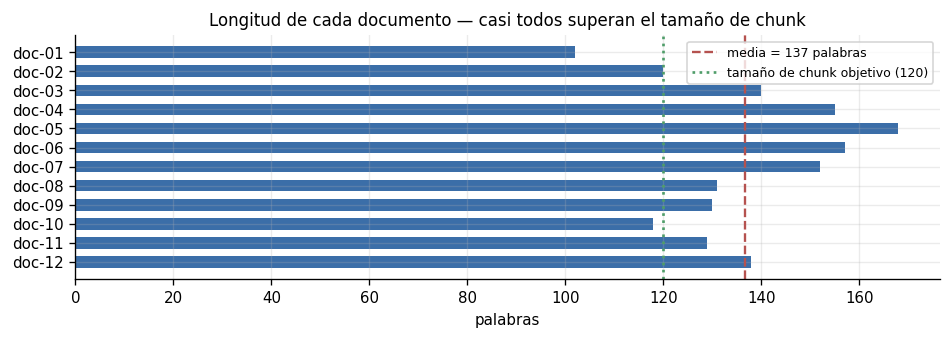

In [ ]:
# 📊 Distribución de longitudes: ¿necesitamos trocear?
fig, ax = plt.subplots(figsize=(8, 2.9))
longs = [d["n_palabras"] for d in DOCUMENTOS]
ax.barh([d["id"] for d in DOCUMENTOS], longs, color=PALETA[0], height=0.62)
ax.axvline(np.mean(longs), color=PALETA[3], ls="--", lw=1.4,
           label=f"media = {np.mean(longs):.0f} palabras")
ax.axvline(120, color=PALETA[2], ls=":", lw=1.6, label="tamaño de chunk objetivo (120)")
ax.invert_yaxis(); ax.set_xlabel("palabras"); ax.legend(fontsize=7.5)
ax.set_title("Longitud de cada documento — casi todos superan el tamaño de chunk", fontsize=10)
plt.tight_layout(); plt.show()

---
# 2 · Capa de Chunking (troceado)

> **Objetivo:** partir cada documento en fragmentos que sean, a la vez, **una unidad semántica**
> y **una unidad recuperable**.

### 2.1 El compromiso fundamental

```
chunk MUY PEQUEÑO (50 palabras)          chunk MUY GRANDE (1000 palabras)
├─ ✅ vector muy preciso, un solo tema   ├─ ✅ el LLM recibe contexto suficiente
├─ ❌ le falta contexto para responder   ├─ ❌ el vector es un "promedio borroso"
└─ ❌ muchos chunks → índice más grande   └─ ❌ desperdicia ventana de contexto
```

El vector de un chunk es, aproximadamente, el **centroide semántico** de todo lo que contiene.
Si un chunk habla de tres temas, su vector no queda cerca de ninguno de los tres. A esto se le
llama **dilución semántica**.

### 2.2 Tres estrategias

| Estrategia | Cómo corta | Cuándo usarla |
|---|---|---|
| **Fijo con solape** | cada N palabras, con solape del 10–20 % | corpus homogéneo, punto de partida siempre válido |
| **Por estructura** | respeta párrafos, títulos, listas | documentación técnica, Markdown, HTML |
| **Semántico** | corta donde cae la similitud entre frases | prosa continua sin estructura clara |

### 2.3 El truco que más rinde: *contextual chunk headers*

Antepón el **título del documento y de la sección** al texto de cada chunk **antes** de calcular su
embedding. Un chunk que dice *"debe cumplir ef_search ≥ k"* es incomprensible aislado; convertido en
*"Parámetros de HNSW › Indexación: debe cumplir ef_search ≥ k"* se vuelve recuperable.
Ese prefijo se usa **sólo para el embedding**; al LLM le pasas el texto original.

In [ ]:
def trocear_fijo(texto: str, tam: int = 120, solape: int = 24) -> List[str]:
    """Ventana deslizante sobre palabras. tam y solape en PALABRAS."""
    palabras = texto.split()
    if len(palabras) <= tam:
        return [texto]
    paso, trozos, i = tam - solape, [], 0
    while i < len(palabras):
        trozos.append(" ".join(palabras[i:i + tam]))
        if i + tam >= len(palabras):
            break
        i += paso
    return trozos

def trocear_por_frases(texto: str, tam: int = 120, solape_frases: int = 1) -> List[str]:
    """Agrupa frases completas hasta llegar a `tam` palabras. Nunca parte una frase por la mitad."""
    frases = [f.strip() for f in re.split(r"(?<=[.!?])\s+", texto) if f.strip()]
    trozos, actual, n = [], [], 0
    for f in frases:
        nf = len(f.split())
        if n + nf > tam and actual:
            trozos.append(" ".join(actual))
            actual = actual[-solape_frases:] if solape_frases else []   # solape por frases
            n = sum(len(x.split()) for x in actual)
        actual.append(f); n += nf
    if actual:
        trozos.append(" ".join(actual))
    return trozos

# --- Comparación visual de ambas estrategias ---
demo = DOCUMENTOS[4]["texto"]
a, b = trocear_fijo(demo), trocear_por_frases(demo)
print(f"Documento de prueba: '{DOCUMENTOS[4]['titulo']}' ({len(demo.split())} palabras)\n")
print(f"  Fijo con solape  -> {len(a)} chunks, tamaños {[len(x.split()) for x in a]}")
print(f"  Por frases       -> {len(b)} chunks, tamaños {[len(x.split()) for x in b]}\n")
print("⚠️  Fin del chunk 1 con troceado FIJO (fíjate en el corte a mitad de frase):")
print("   ...", a[0][-160:], "✂️")
print("\n✅ Fin del chunk 1 con troceado POR FRASES:")
print("   ...", b[0][-160:], "✂️")

Documento de prueba: 'Parámetros de HNSW' (168 palabras)

  Fijo con solape  -> 2 chunks, tamaños [120, 72]
  Por frases       -> 2 chunks, tamaños [103, 97]

⚠️  Fin del chunk 1 con troceado FIJO (fíjate en el corte a mitad de frase):
   ... ción mayor; no afecta a la memoria final ni a la latencia de consulta. El tercero es ef_search, el tamaño de la lista de candidatos durante la búsqueda, y es el ✂️

✅ Fin del chunk 1 con troceado POR FRASES:
   ... tos, entre 100 y 500, producen un grafo de mejor calidad a costa de un tiempo de construcción mayor; no
 afecta a la memoria final ni a la latencia de consulta. ✂️


In [ ]:
@traceable(name="2-chunking", run_type="chain")
def construir_chunks(documentos: List[Dict], tam: int = 120, solape_frases: int = 1) -> List[Dict]:
    """Devuelve la lista final de chunks con metadatos y el texto enriquecido para embedding."""
    chunks = []
    for doc in documentos:
        trozos = trocear_por_frases(doc["texto"], tam=tam, solape_frases=solape_frases)
        for j, t in enumerate(trozos):
            chunks.append({
                "chunk_id":   f"{doc['id']}::c{j}",
                "doc_id":     doc["id"],
                "titulo":     doc["titulo"],
                "seccion":    doc["seccion"],
                "fuente":     doc["fuente"],
                "fecha":      doc["fecha"],
                "posicion":   j,
                "texto":      t,                                          # ← lo que ve el LLM
                "texto_emb":  f"{doc['titulo']} › {doc['seccion']}: {t}",  # ← lo que se vectoriza
                "n_palabras": len(t.split()),
            })
    return chunks

CHUNKS = construir_chunks(DOCUMENTOS)
print(f"✅ {len(DOCUMENTOS)} documentos → {len(CHUNKS)} chunks "
      f"(media {np.mean([c['n_palabras'] for c in CHUNKS]):.0f} palabras)\n")
print("Ejemplo de texto_emb (con cabecera contextual):\n")
print(textwrap.fill(CHUNKS[9]["texto_emb"][:330], 96), "...")

✅ 12 documentos → 21 chunks (media 91 palabras)

Ejemplo de texto_emb (con cabecera contextual):

Estrategias de chunking › Preprocesamiento: El troceado por estructura  respeta títulos,
párrafos y listas del documento original y suele funcionar mejor en documentación técnica. El
troceado semántico corta allí donde la similitud entre frases consecutivas cae por debajo de un
umbral. Una técnica complementaria muy eficaz es el ...


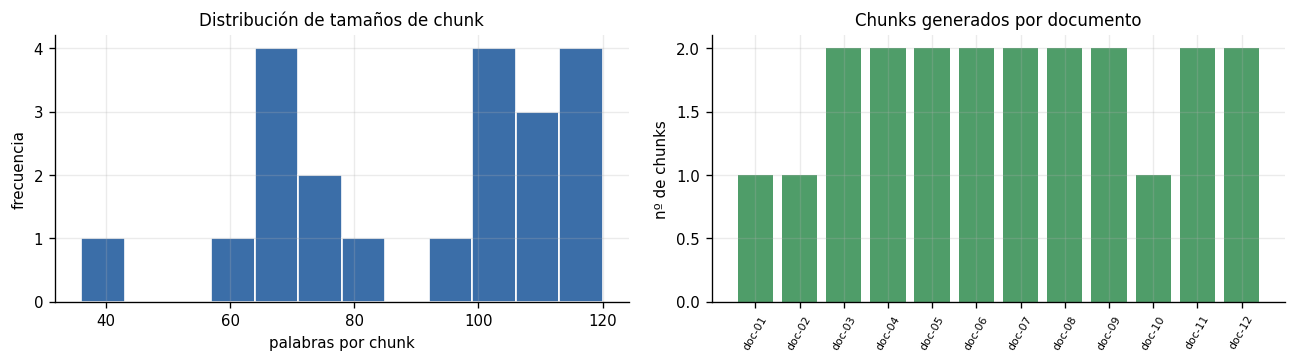

In [ ]:
# 📊 Cómo queda el corpus troceado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.1))

ax1.hist([c["n_palabras"] for c in CHUNKS], bins=12, color=PALETA[0], edgecolor="white")
ax1.set_xlabel("palabras por chunk"); ax1.set_ylabel("frecuencia")
ax1.set_title("Distribución de tamaños de chunk", fontsize=10)

docs_ids = [d["id"] for d in DOCUMENTOS]
conteo = [sum(1 for c in CHUNKS if c["doc_id"] == i) for i in docs_ids]
ax2.bar(docs_ids, conteo, color=PALETA[2])
ax2.set_ylabel("nº de chunks"); ax2.tick_params(axis="x", rotation=60, labelsize=6.5)
ax2.set_title("Chunks generados por documento", fontsize=10)
plt.tight_layout(); plt.show()

---
# 3 · Capa de Embeddings

> **Objetivo:** proyectar cada chunk a un vector $\mathbf{v} \in \mathbb{R}^d$ donde la **cercanía
> geométrica** equivalga a **cercanía de significado**.

### 3.1 La matemática mínima que necesitas

La similitud coseno entre dos vectores es:

$$\text{sim}(\mathbf{a},\mathbf{b}) = \cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}$$

Si **normalizamos** todos los vectores a norma 1 ($\lVert\mathbf{a}\rVert = 1$), entonces:

$$\text{sim}(\mathbf{a},\mathbf{b}) = \mathbf{a}\cdot\mathbf{b} \qquad\text{y}\qquad \lVert\mathbf{a}-\mathbf{b}\rVert^2 = 2 - 2(\mathbf{a}\cdot\mathbf{b})$$

👉 **Consecuencia práctica:** con vectores normalizados, *ordenar por coseno descendente* es
**idéntico** a *ordenar por distancia euclídea ascendente*. Por eso podemos usar el espacio
`'cosine'` o `'l2'` de hnswlib indistintamente. **Normaliza siempre.**

### 3.2 Bi-encoder vs cross-encoder

* **Bi-encoder** (lo de esta capa): codifica consulta y documento **por separado**. Permite
  precalcular todos los vectores del corpus → búsqueda en milisegundos. Menos preciso.
* **Cross-encoder** (capa 6): procesa consulta y documento **juntos**. Mucho más preciso, pero
  requiere una pasada del modelo por cada par → sólo viable para reordenar ~50 candidatos.

### 3.3 Backend con *fallback* offline

Usamos `sentence-transformers` con un modelo **multilingüe**. Si no está disponible (sin red, sin
GPU, entorno restringido) caemos a un backend **TF-IDF + SVD** (*LSA*) que produce vectores densos
con la misma interfaz. Los resultados son peores, pero **todo el cuaderno sigue funcionando** y las
lecciones sobre HNSW son idénticas.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize as sk_normalize

class BackendEmbeddings:
    """
    Interfaz única para vectorizar texto.
      .ajustar(textos)   -> entrena (sólo lo necesita el fallback TF-IDF)
      .codificar(textos) -> np.ndarray (n, d) float32 NORMALIZADO a norma 1
    """
    def __init__(self, modelo="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                 dim_fallback=192, forzar_fallback=False):
        self.nombre, self.tipo, self.modelo = modelo, None, None
        if not forzar_fallback:
            try:
                from sentence_transformers import SentenceTransformer
                self.modelo = SentenceTransformer(modelo)
                self.dim  = self.modelo.get_sentence_embedding_dimension()
                self.tipo = "sentence-transformers"
            except Exception as e:
                print(f"  ⚠️  No se pudo cargar '{modelo}' ({type(e).__name__}).")
                print("      → Se usará el backend TF-IDF+SVD (offline).")
        if self.tipo is None:
            self.tipo   = "tfidf-svd"
            self.nombre = f"TF-IDF+SVD(d={dim_fallback})"
            self.dim    = dim_fallback
            self._tfidf = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2),
                                          min_df=1, max_df=0.9, strip_accents="unicode",
                                          lowercase=True)
            self._svd, self._ajustado = None, False

    def ajustar(self, textos: List[str]):
        if self.tipo == "tfidf-svd":
            X = self._tfidf.fit_transform(textos)
            d = min(self.dim, X.shape[1] - 1, max(2, X.shape[0] - 1))
            self._svd = TruncatedSVD(n_components=d, random_state=42).fit(X)
            self.dim, self._ajustado = d, True
        return self

    def codificar(self, textos, lote=64, barra=False) -> np.ndarray:
        if isinstance(textos, str):
            textos = [textos]
        if self.tipo == "sentence-transformers":
            V = self.modelo.encode(list(textos), batch_size=lote,
                                   show_progress_bar=barra, convert_to_numpy=True)
        else:
            if not self._ajustado:
                raise RuntimeError("Llama antes a .ajustar(corpus) con el backend TF-IDF.")
            V = self._svd.transform(self._tfidf.transform(list(textos)))
        V = sk_normalize(np.asarray(V, dtype=np.float32))   # ← CLAVE: norma 1
        return V.astype(np.float32)

print("Cargando backend de embeddings…")
EMB = BackendEmbeddings().ajustar([c["texto_emb"] for c in CHUNKS])
print(f"\n✅ Backend: {EMB.tipo}  ·  modelo: {EMB.nombre}  ·  dimensión d = {EMB.dim}")

Cargando backend de embeddings…


  ⚠️  No se pudo cargar 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2' (ProxyError).
      → Se usará el backend TF-IDF+SVD (offline).

✅ Backend: tfidf-svd  ·  modelo: TF-IDF+SVD(d=192)  ·  dimensión d = 20


In [ ]:
# Vectorizamos TODO el corpus de chunks
t0 = time.perf_counter()
VECTORES = EMB.codificar([c["texto_emb"] for c in CHUNKS], barra=False)
t_emb = time.perf_counter() - t0

print(f"Matriz de embeddings: {VECTORES.shape}  ({VECTORES.dtype})")
print(f"Tiempo: {t_emb*1000:.0f} ms  →  {len(CHUNKS)/max(t_emb,1e-9):.0f} chunks/s")
print(f"Norma de cada vector: min={np.linalg.norm(VECTORES,axis=1).min():.4f} "
      f"max={np.linalg.norm(VECTORES,axis=1).max():.4f}   (deben ser 1.0 ✅)")
print(f"Memoria de los vectores: {VECTORES.nbytes/1024:.1f} KB "
      f"→ para 1M de chunks serían {EMB.dim*4*1_000_000/1e9:.2f} GB")

Matriz de embeddings: (21, 20)  (float32)
Tiempo: 5 ms  →  4042 chunks/s
Norma de cada vector: min=1.0000 max=1.0000   (deben ser 1.0 ✅)
Memoria de los vectores: 1.6 KB → para 1M de chunks serían 0.08 GB


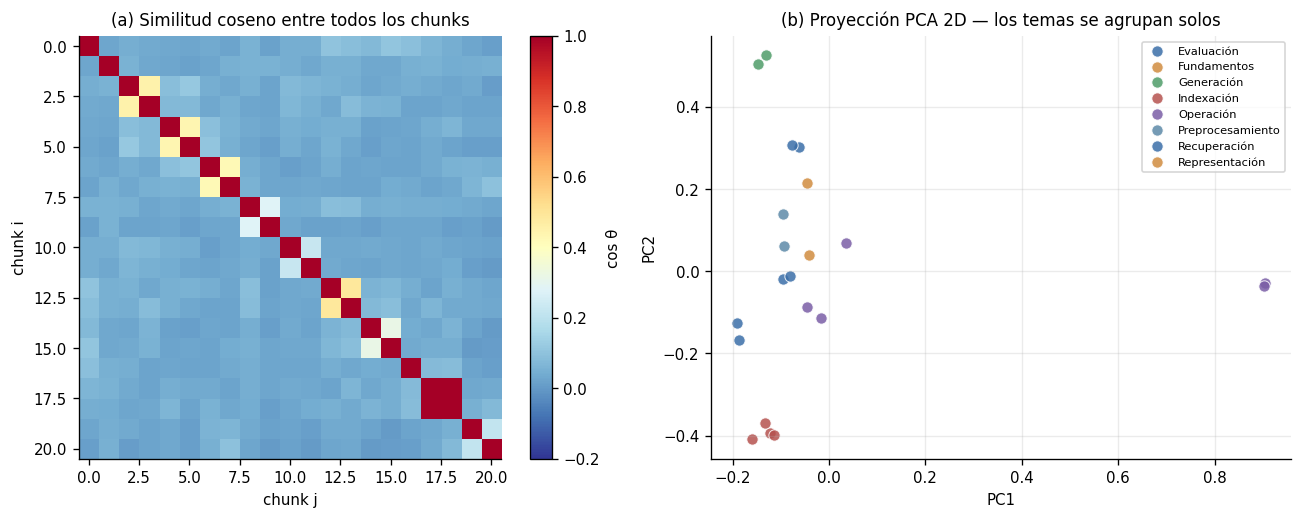

cos(a,b)              = 0.027903
2 - 2·cos(a,b)        = 1.944195
‖a-b‖²                = 1.944195   ← idénticos ✅


In [ ]:
# 🖼️ Dos vistas del espacio de embeddings
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(11.5, 4.4))

# --- (a) Matriz de similitud coseno = producto interno ---
ax1 = fig.add_subplot(1, 2, 1)
S = VECTORES @ VECTORES.T
im = ax1.imshow(S, cmap="RdYlBu_r", vmin=-0.2, vmax=1)
ax1.set_title("(a) Similitud coseno entre todos los chunks", fontsize=10)
ax1.set_xlabel("chunk j"); ax1.set_ylabel("chunk i"); ax1.grid(False)
plt.colorbar(im, ax=ax1, fraction=0.046, label="cos θ")

# --- (b) Proyección PCA a 2D coloreada por sección ---
ax2 = fig.add_subplot(1, 2, 2)
P = PCA(n_components=2, random_state=0).fit_transform(VECTORES)
secciones = sorted({c["seccion"] for c in CHUNKS})
for k, s in enumerate(secciones):
    idx = [i for i, c in enumerate(CHUNKS) if c["seccion"] == s]
    ax2.scatter(P[idx, 0], P[idx, 1], s=46, alpha=0.85,
                color=PALETA[k % len(PALETA)], label=s, edgecolor="white", linewidth=0.6)
ax2.legend(fontsize=6.8, loc="best", frameon=True)
ax2.set_title("(b) Proyección PCA 2D — los temas se agrupan solos", fontsize=10)
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")

plt.tight_layout(); plt.show()

# Comprobación numérica de la identidad coseno ↔ distancia euclídea
a, b = VECTORES[0], VECTORES[5]
print(f"cos(a,b)              = {float(a@b):.6f}")
print(f"2 - 2·cos(a,b)        = {2-2*float(a@b):.6f}")
print(f"‖a-b‖²                = {float(np.sum((a-b)**2)):.6f}   ← idénticos ✅")

---
# 4 · Capa de Indexación: **HNSW**

> **Objetivo:** poder preguntar *"¿cuáles son los k vectores más parecidos a éste?"* en tiempo
> **logarítmico** en lugar de lineal.

### 4.1 El problema

Con búsqueda exacta, cada consulta cuesta $O(n \cdot d)$. Con 10 M de chunks de 768 dimensiones son
**7 700 millones de multiplicaciones por pregunta**. Inviable.

Los árboles KD tampoco sirven: a partir de ~20 dimensiones la **maldición de la dimensionalidad**
hace que tengan que explorar casi todas las ramas y acaban siendo *más lentos* que la fuerza bruta.

### 4.2 La idea de HNSW, en tres pasos

**HNSW = Hierarchical Navigable Small World** (Malkov & Yashunin, 2016).

1. **Grafo de proximidad.** Conecta cada vector con sus vecinos más cercanos. Buscar = caminar por
   el grafo hacia la consulta, con una estrategia voraz. Problema: si empiezas lejos, tardas muchísimo.
2. **Small world.** Añade unas pocas aristas *largas* al azar. Ahora el diámetro del grafo es
   $O(\log n)$: se llega a cualquier sitio en pocos saltos.
3. **Hierarchical.** En vez de mezclar aristas largas y cortas en un solo grafo, se **estratifican
   por capas**. A cada elemento se le asigna un nivel máximo con
   $\ell = \lfloor -\ln(U) \cdot m_L \rfloor$, $U\sim\mathcal{U}(0,1)$ → distribución exponencial:
   la capa 0 tiene todos los elementos, cada capa superior ~$1/e$ de la anterior.

**La búsqueda es como viajar:** ✈️ avión entre capitales (capas altas) → 🚗 autopista → 🚶 calles del
barrio (capa 0).

### 4.3 Los tres parámetros

| Parámetro | Qué controla | ↑ Subirlo | Se cambia en caliente |
|---|---|---|---|
| **`M`** | conexiones por nodo (capa 0 usa `2M`) | ↑ recall, ↑↑ **memoria**, ↑ tiempo de construcción | ❌ hay que reconstruir |
| **`ef_construction`** | candidatos durante la **inserción** | ↑ calidad del grafo, ↑↑ tiempo de build. **No** afecta a memoria ni a latencia | ❌ hay que reconstruir |
| **`ef_search`** | candidatos durante la **búsqueda** | ↑ recall, ↑ latencia (≈ lineal). Requiere `ef_search ≥ k` | ✅ **sí** — tu palanca de producción |

**Memoria aproximada:** $\text{bytes} \approx n \cdot (d \cdot 4 + M \cdot 8)$

### 4.4 Visualicemos la estructura

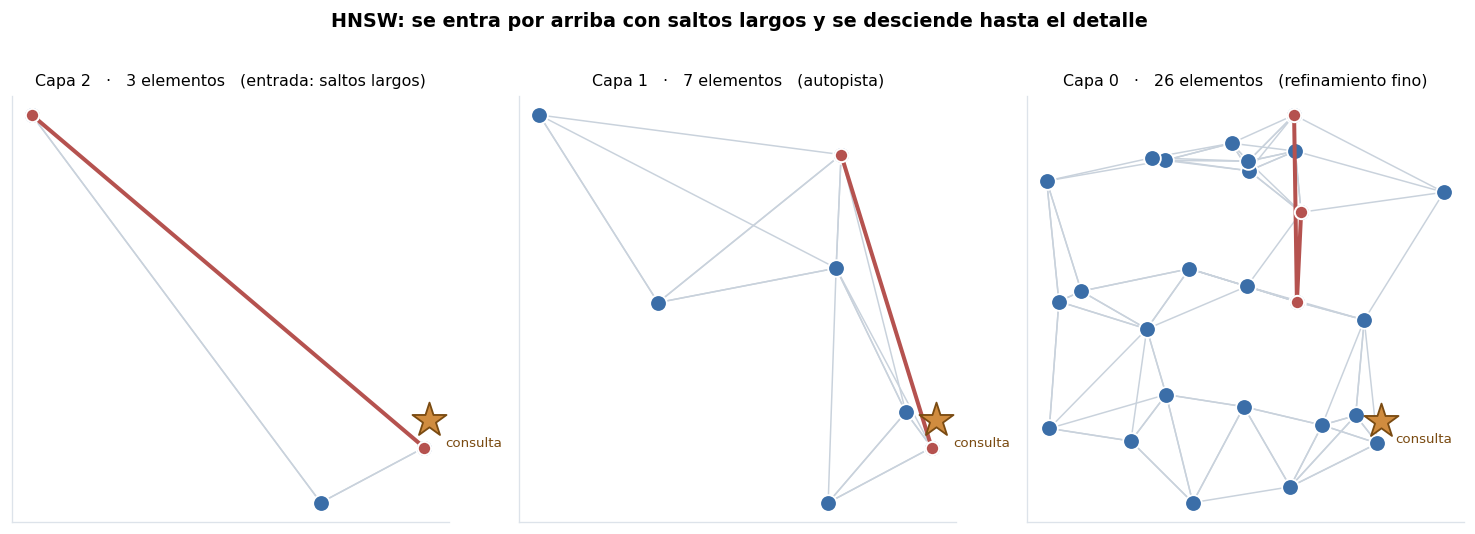

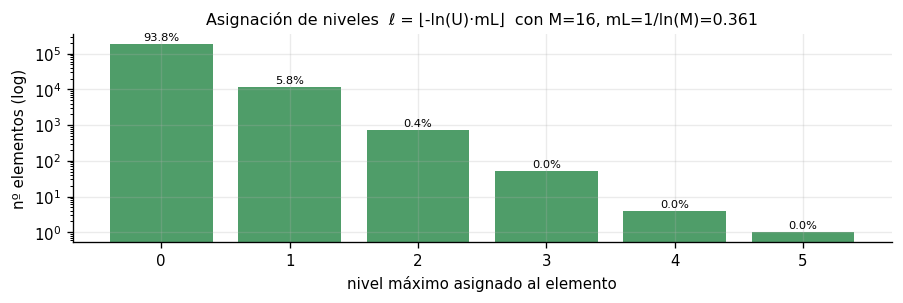

In [ ]:
def diagrama_hnsw():
    """Dibuja la estructura por capas de HNSW y el recorrido de una búsqueda."""
    r = np.random.default_rng(7)
    n0 = 26
    pos = r.uniform(0, 10, size=(n0, 2))                    # posiciones 2D de los elementos
    niveles = {2: [3, 11, 19], 1: [1, 3, 6, 11, 14, 19, 22], 0: list(range(n0))}
    consulta = np.array([8.4, 2.1])
    camino   = {2: [3, 19], 1: [19, 22], 0: [22, 14, 9]}     # recorrido ilustrativo

    fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.3))
    for ax, capa in zip(axes, [2, 1, 0]):
        ids = niveles[capa]
        P = pos[ids]
        # aristas: k vecinos más cercanos dentro de la capa
        k = {2: 2, 1: 3, 0: 4}[capa]
        for i in range(len(ids)):
            d = np.linalg.norm(P - P[i], axis=1); d[i] = 1e9
            for j in np.argsort(d)[:k]:
                ax.plot([P[i,0], P[j,0]], [P[i,1], P[j,1]], color="#C9D2DC", lw=0.9, zorder=1)
        ax.scatter(P[:,0], P[:,1], s=100, color=PALETA[0], edgecolor="white", lw=1.1, zorder=3)
        # recorrido de búsqueda
        cam = camino[capa]
        CP = pos[cam]
        ax.plot(CP[:,0], CP[:,1], color=PALETA[3], lw=2.4, zorder=4,
                marker="o", ms=8, mec="white", mew=1.2)
        ax.scatter(*consulta, marker="*", s=460, color=PALETA[1],
                   edgecolor="#7A4B12", lw=1.1, zorder=5)
        ax.text(consulta[0]+0.35, consulta[1]-0.55, "consulta", fontsize=8, color="#7A4B12")
        ax.set_title(f"Capa {capa}   ·   {len(ids)} elementos" +
                     ("   (entrada: saltos largos)" if capa == 2 else "   (refinamiento fino)" if capa == 0 else "   (autopista)"),
                     fontsize=9.5)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values(): s.set_edgecolor("#DDE3EA")
    fig.suptitle("HNSW: se entra por arriba con saltos largos y se desciende hasta el detalle",
                 fontsize=11.5, fontweight="bold", y=1.02)
    plt.tight_layout(); plt.show()

diagrama_hnsw()

# Distribución exponencial de niveles: la razón de que la pirámide se estreche
M_demo, N_demo = 16, 200_000
mL = 1/np.log(M_demo)
niveles_sim = np.floor(-np.log(np.random.default_rng(0).random(N_demo)) * mL).astype(int)
fig, ax = plt.subplots(figsize=(7.6, 2.6))
vals, cuentas = np.unique(niveles_sim, return_counts=True)
ax.bar(vals, cuentas, color=PALETA[2])
ax.set_yscale("log"); ax.set_xlabel("nivel máximo asignado al elemento")
ax.set_ylabel("nº elementos (log)")
ax.set_title(f"Asignación de niveles  ℓ = ⌊-ln(U)·mL⌋  con M={M_demo}, mL=1/ln(M)={mL:.3f}", fontsize=9.5)
for v, c in zip(vals, cuentas):
    ax.text(v, c*1.25, f"{c/N_demo*100:.1f}%", ha="center", fontsize=6.8)
plt.tight_layout(); plt.show()

### 4.5 Construimos el índice con `hnswlib`

Puntos de API importantes:

```python
index = hnswlib.Index(space='cosine', dim=d)     # space: 'cosine' | 'l2' | 'ip'
index.init_index(max_elements=N, ef_construction=200, M=16)
index.add_items(vectores, ids)                   # ids enteros → mapea a tus chunks
index.set_ef(64)                                 # ef_search, en caliente
labels, distancias = index.knn_query(q, k=5)
```

⚠️ **`hnswlib` devuelve DISTANCIAS, no similitudes.** Con `space='cosine'` devuelve
`1 - cos θ`, así que la **similitud es `1 - distancia`**. Confundirlo es el bug nº 1 de los
principiantes: se ordena al revés y el sistema recupera lo *menos* relevante.

In [ ]:
import hnswlib

@traceable(name="4-indexacion-hnsw", run_type="chain")
def construir_indice(vectores: np.ndarray, M=16, ef_construction=200, espacio="cosine"):
    n, d = vectores.shape
    idx = hnswlib.Index(space=espacio, dim=d)
    idx.init_index(max_elements=n, ef_construction=ef_construction, M=M, random_seed=42)
    t0 = time.perf_counter()
    idx.add_items(vectores, np.arange(n))
    dt = time.perf_counter() - t0
    idx.set_ef(max(64, 2 * M))                       # ef_search por defecto razonable
    return idx, dt

INDICE, T_BUILD = construir_indice(VECTORES, M=16, ef_construction=200)

n, d, M = VECTORES.shape[0], EMB.dim, 16
mem_estimada = n * (d * 4 + M * 8)
print(f"✅ Índice HNSW construido")
print(f"   elementos        : {INDICE.get_current_count()}")
print(f"   dimensión        : {d}")
print(f"   espacio          : cosine  (distancia = 1 - cos θ)")
print(f"   M = 16, ef_construction = 200, ef_search = {INDICE.ef}")
print(f"   tiempo de build  : {T_BUILD*1000:.1f} ms  ({n/max(T_BUILD,1e-9):.0f} vec/s)")
print(f"   memoria estimada : {mem_estimada/1024:.1f} KB   →  {mem_estimada/n*1_000_000/1e9:.2f} GB por millón de vectores")

# Persistencia (así se guarda un índice en producción)
INDICE.save_index("indice_rag.bin")
print("\n💾 Índice guardado en 'indice_rag.bin' "
      "(para recargarlo: idx.load_index('indice_rag.bin', max_elements=N))")

✅ Índice HNSW construido
   elementos        : 21
   dimensión        : 20
   espacio          : cosine  (distancia = 1 - cos θ)
   M = 16, ef_construction = 200, ef_search = 64
   tiempo de build  : 0.7 ms  (30898 vec/s)
   memoria estimada : 4.3 KB   →  0.21 GB por millón de vectores

💾 Índice guardado en 'indice_rag.bin' (para recargarlo: idx.load_index('indice_rag.bin', max_elements=N))


   M  ef_constr  build(s)  recall@10   mem(MB)
----------------------------------------------
   4         40      0.12      0.738       0.9
   4        200      0.44      0.787       0.9
   8         40      0.13      0.943       1.2
   8        200      0.47      0.953       1.2
  16         40      0.14      0.990       1.7
  16        200      0.50      0.988       1.7
  32         40      0.16      0.993       2.7
  32        200      0.64      0.998       2.7
  64         40      0.30      0.995       4.7
  64        200      0.67      0.998       4.7


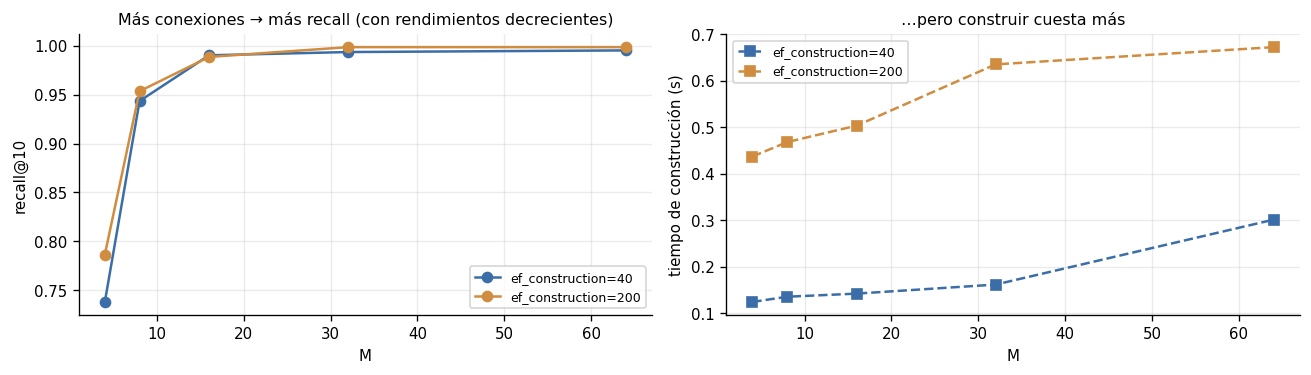

In [ ]:
# 🔬 ¿Cómo afectan M y ef_construction? Experimento controlado.
# Aumentamos artificialmente el corpus con ruido para que las diferencias sean visibles.
N_SINT, D_SINT = 8000, EMB.dim
base = rng.normal(size=(N_SINT, D_SINT)).astype(np.float32)
base = sk_normalize(base)
CONS_SINT = sk_normalize(rng.normal(size=(60, D_SINT)).astype(np.float32))
K = 10

# Verdad de referencia por fuerza bruta
VERDAD = np.argsort(-(CONS_SINT @ base.T), axis=1)[:, :K]

def recall_medio(idx, ef, verdad=VERDAD, k=K):
    idx.set_ef(ef)
    etiquetas, _ = idx.knn_query(CONS_SINT, k=k)
    return float(np.mean([len(set(a) & set(b)) / k for a, b in zip(etiquetas, verdad)]))

filas = []
for M_ in [4, 8, 16, 32, 64]:
    for efc in [40, 200]:
        ix = hnswlib.Index(space="ip", dim=D_SINT)   # vectores normalizados ⇒ ip ≡ coseno
        ix.init_index(max_elements=N_SINT, ef_construction=efc, M=M_, random_seed=1)
        t0 = time.perf_counter(); ix.add_items(base, np.arange(N_SINT)); tb = time.perf_counter()-t0
        filas.append({"M": M_, "efc": efc, "build_s": tb,
                      "recall@10 (ef=64)": recall_medio(ix, 64),
                      "mem_MB": N_SINT*(D_SINT*4 + M_*8)/1e6})

print(f"{'M':>4} {'ef_constr':>10} {'build(s)':>9} {'recall@10':>10} {'mem(MB)':>9}")
print("-"*46)
for f in filas:
    print(f"{f['M']:>4} {f['efc']:>10} {f['build_s']:>9.2f} {f['recall@10 (ef=64)']:>10.3f} {f['mem_MB']:>9.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2))
for k_, efc in enumerate([40, 200]):
    sub = [f for f in filas if f["efc"] == efc]
    ax1.plot([f["M"] for f in sub], [f["recall@10 (ef=64)"] for f in sub],
             "o-", color=PALETA[k_], label=f"ef_construction={efc}")
    ax2.plot([f["M"] for f in sub], [f["build_s"] for f in sub],
             "s--", color=PALETA[k_], label=f"ef_construction={efc}")
ax1.set_xlabel("M"); ax1.set_ylabel("recall@10"); ax1.legend(fontsize=7.5)
ax1.set_title("Más conexiones → más recall (con rendimientos decrecientes)", fontsize=9.5)
ax2.set_xlabel("M"); ax2.set_ylabel("tiempo de construcción (s)"); ax2.legend(fontsize=7.5)
ax2.set_title("…pero construir cuesta más", fontsize=9.5)
plt.tight_layout(); plt.show()

---
# 5 · Capa de Recuperación (*retrieval*)

> **Objetivo:** dada una pregunta, devolver los `k` chunks más útiles — rápido y con buen *recall*.

Aquí vive el parámetro que **más vas a tocar en producción**: `ef_search`.

In [ ]:
@dataclass
class Resultado:
    chunk_id: str; texto: str; titulo: str; seccion: str
    fuente: str;   similitud: float; indice: int

    def __repr__(self):
        return f"<{self.chunk_id} sim={self.similitud:.3f} · {self.titulo}>"

@traceable(name="5-retrieval-denso", run_type="retriever")
def buscar_denso(consulta: str, k: int = 5, ef: int = 64,
                 filtro=None) -> List[Resultado]:
    """
    Búsqueda densa sobre el índice HNSW.
      filtro: callable(idx:int) -> bool, aplicado DURANTE el recorrido del grafo.
    """
    q = EMB.codificar([consulta])
    INDICE.set_ef(max(ef, k))
    etiquetas, distancias = INDICE.knn_query(q, k=k, filter=filtro)
    salida = []
    for lab, dist in zip(etiquetas[0], distancias[0]):
        c = CHUNKS[int(lab)]
        salida.append(Resultado(
            chunk_id=c["chunk_id"], texto=c["texto"], titulo=c["titulo"],
            seccion=c["seccion"], fuente=c["fuente"],
            similitud=float(1.0 - dist),           # ⚠️ distancia → similitud
            indice=int(lab)))
    return salida

def mostrar(resultados, ancho=92, n_car=190):
    for i, r in enumerate(resultados, 1):
        barra = "█" * int(max(r.similitud, 0) * 22)
        print(f"\n[{i}] {r.similitud:+.3f} {barra:<22} {r.titulo}  ·  {r.seccion}")
        print(textwrap.fill(r.texto[:n_car] + "…", ancho, initial_indent="    ",
                            subsequent_indent="    "))

CONSULTA = "¿Para qué sirve el parámetro ef_search y cómo afecta al rendimiento?"
print(f"❓ {CONSULTA}")
mostrar(buscar_denso(CONSULTA, k=4))

❓ ¿Para qué sirve el parámetro ef_search y cómo afecta al rendimiento?

[1] +0.590 ████████████           Producción: memoria, filtros y actualización  ·  Operación
    hnswlib lo  soporta con el parámetro filter de knn_query. Por último, HNSW admite
    inserciones incrementales pero no borrados reales: marcar como borrado degrada el  grafo
    con el tiempo, de m…

[2] +0.561 ████████████           Parámetros de HNSW  ·  Indexación
    Valores  altos, entre 100 y 500, producen un grafo de mejor calidad a costa de un tiempo
    de construcción mayor; no  afecta a la memoria final ni a la latencia de consulta. El
    tercero es ef_s…

[3] +0.493 ██████████             Diseño del prompt y alucinaciones  ·  Generación
    En la capa de generación el contexto recuperado se inserta en el prompt junto con la
    pregunta. Tres reglas  reducen drásticamente las alucinaciones. Primero, instruir
    explícitamente al model…

[4] +0.301 ██████                 Producción: memoria, filtros y actu

### 5.1 La curva que hay que conocer: `ef_search` ↔ *recall* ↔ latencia

`ef_search` es el tamaño de la lista dinámica de candidatos. Es el **único** parámetro ajustable
sin reconstruir el índice, y describe una curva clásica de **rendimientos decrecientes**:
subir de 10 a 50 dispara el recall; subir de 200 a 500 casi no aporta y duplica la latencia.

**Procedimiento en producción:** fija tu SLA de latencia (p. ej. p95 < 20 ms) y elige el `ef_search`
más alto que lo respete.

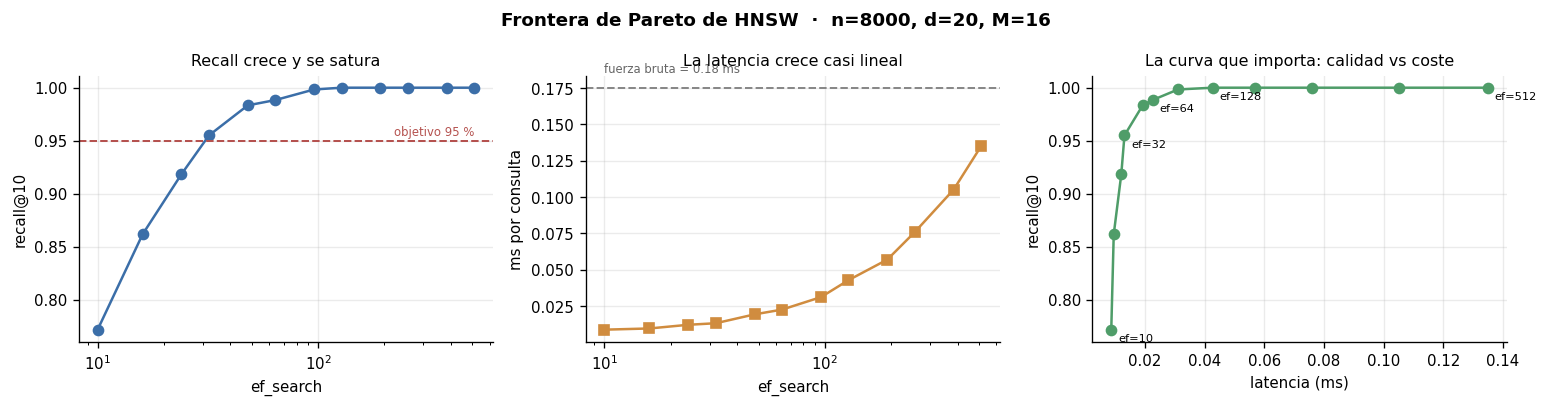

👉 ef_search = 32 alcanza recall 0.955 en 0.01 ms (13× más rápido que la fuerza bruta)


In [ ]:
# Barrido de ef_search sobre el corpus sintético (para tener estadística suficiente)
ix = hnswlib.Index(space="ip", dim=D_SINT)
ix.init_index(max_elements=N_SINT, ef_construction=200, M=16, random_seed=1)
ix.add_items(base, np.arange(N_SINT))

EFS = [10, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]
recalls, latencias = [], []
for ef in EFS:
    ix.set_ef(ef)
    ix.knn_query(CONS_SINT[:5], k=K)                      # calentamiento
    t0 = time.perf_counter()
    lab, _ = ix.knn_query(CONS_SINT, k=K)
    latencias.append((time.perf_counter()-t0)/len(CONS_SINT)*1000)
    recalls.append(np.mean([len(set(a) & set(b))/K for a, b in zip(lab, VERDAD)]))

# Referencia: fuerza bruta
t0 = time.perf_counter(); _ = np.argsort(-(CONS_SINT @ base.T), axis=1)[:, :K]
lat_bruta = (time.perf_counter()-t0)/len(CONS_SINT)*1000

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.4))

ax1.plot(EFS, recalls, "o-", color=PALETA[0]); ax1.axhline(0.95, ls="--", color=PALETA[3], lw=1.2)
ax1.text(EFS[-1], 0.955, "objetivo 95 %", ha="right", fontsize=7, color=PALETA[3])
ax1.set_xscale("log"); ax1.set_xlabel("ef_search"); ax1.set_ylabel("recall@10")
ax1.set_title("Recall crece y se satura", fontsize=9.5)

ax2.plot(EFS, latencias, "s-", color=PALETA[1])
ax2.axhline(lat_bruta, ls="--", color="#888", lw=1.2)
ax2.text(EFS[0], lat_bruta*1.06, f"fuerza bruta = {lat_bruta:.2f} ms", fontsize=7, color="#666")
ax2.set_xscale("log"); ax2.set_xlabel("ef_search"); ax2.set_ylabel("ms por consulta")
ax2.set_title("La latencia crece casi lineal", fontsize=9.5)

ax3.plot(latencias, recalls, "o-", color=PALETA[2])
for ef, x, y in zip(EFS, latencias, recalls):
    if ef in (10, 32, 64, 128, 512):
        ax3.annotate(f"ef={ef}", (x, y), fontsize=6.8, xytext=(4, -7), textcoords="offset points")
ax3.set_xlabel("latencia (ms)"); ax3.set_ylabel("recall@10")
ax3.set_title("La curva que importa: calidad vs coste", fontsize=9.5)

plt.suptitle(f"Frontera de Pareto de HNSW  ·  n={N_SINT}, d={D_SINT}, M=16", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

mejor = max([(r, e, l) for r, e, l in zip(recalls, EFS, latencias) if r >= 0.95], default=None,
            key=lambda t: -t[1])
if mejor:
    print(f"👉 ef_search = {mejor[1]} alcanza recall {mejor[0]:.3f} en {mejor[2]:.2f} ms "
          f"({lat_bruta/mejor[2]:.0f}× más rápido que la fuerza bruta)")

### 5.2 Validación honesta: ¿miente HNSW en *nuestro* corpus?

Nuestro corpus es pequeño, así que podemos calcular la verdad exacta por fuerza bruta y comprobar
el **recall real** del índice. Es una prueba que **siempre** deberías hacer antes de pasar a producción.

In [ ]:
CONSULTAS_TEST = [
    "¿qué es la generación aumentada por recuperación?",
    "cómo elegir el tamaño de los chunks",
    "diferencia entre búsqueda densa y BM25",
    "cuánta memoria consume un índice HNSW",
    "cómo se mide si la respuesta está fundamentada",
    "qué hace el parámetro M en el grafo",
]
k = 5
Q = EMB.codificar(CONSULTAS_TEST)
verdad = np.argsort(-(Q @ VECTORES.T), axis=1)[:, :k]

print(f"{'consulta':<50} {'recall@5':>9}")
print("-"*61)
rec = []
for i, c in enumerate(CONSULTAS_TEST):
    obtenidos = {r.indice for r in buscar_denso(c, k=k, ef=64)}
    r_ = len(obtenidos & set(verdad[i])) / k
    rec.append(r_)
    print(f"{c[:48]:<50} {r_:>9.2f}")
print("-"*61)
print(f"{'RECALL MEDIO':<50} {np.mean(rec):>9.3f}")
print("\n(En corpus pequeños HNSW suele ser exacto: recall = 1.00. "
      "Las diferencias aparecen con cientos de miles de vectores.)")

consulta                                            recall@5
-------------------------------------------------------------
¿qué es la generación aumentada por recuperación        1.00
cómo elegir el tamaño de los chunks                     1.00
diferencia entre búsqueda densa y BM25                  1.00
cuánta memoria consume un índice HNSW                   1.00
cómo se mide si la respuesta está fundamentada          1.00
qué hace el parámetro M en el grafo                     1.00
-------------------------------------------------------------
RECALL MEDIO                                           1.000

(En corpus pequeños HNSW suele ser exacto: recall = 1.00. Las diferencias aparecen con cientos de miles de vectores.)


### 5.3 Filtrado por metadatos: hazlo **durante** el recorrido, no después

Si filtras *después* de recuperar ("post-filtrado"), pides k=5 y resulta que 4 no cumplen el filtro,
te quedas con 1 resultado. `hnswlib` acepta un `filter` que se evalúa **dentro** del grafo.

In [ ]:
print("🔓 Sin filtro:")
for r in buscar_denso("cómo se organiza el grafo por capas", k=3):
    print(f"    {r.similitud:.3f}  [{r.seccion:<16}] {r.titulo}")

indices_indexacion = {i for i, c in enumerate(CHUNKS) if c["seccion"] == "Indexación"}
print("\n🔒 Filtrado a la sección 'Indexación' (durante el recorrido):")
for r in buscar_denso("cómo se organiza el grafo por capas", k=3,
                      filtro=lambda i: i in indices_indexacion):
    print(f"    {r.similitud:.3f}  [{r.seccion:<16}] {r.titulo}")

🔓 Sin filtro:
    0.748  [Indexación      ] HNSW: grafos navegables jerárquicos
    0.431  [Operación       ] Producción: memoria, filtros y actualización
    0.430  [Operación       ] Orquestación con LangGraph

🔒 Filtrado a la sección 'Indexación' (durante el recorrido):
    0.748  [Indexación      ] HNSW: grafos navegables jerárquicos
    0.307  [Indexación      ] Parámetros de HNSW
    0.214  [Indexación      ] HNSW: grafos navegables jerárquicos


### 5.4 MMR: cuando el *top-k* se llena de clones

Los 5 mejores resultados suelen ser **5 variantes del mismo párrafo**. Eso desperdicia la ventana de
contexto. **Maximal Marginal Relevance** reordena buscando el equilibrio entre relevancia y novedad:

$$\text{MMR} = \arg\max_{d \in R\setminus S}\Big[\lambda\,\text{sim}(d,q) - (1-\lambda)\max_{s\in S}\text{sim}(d,s)\Big]$$

* $\lambda = 1$ → sólo relevancia (equivale a no usar MMR)
* $\lambda = 0.5$ → equilibrio típico
* $\lambda = 0$ → sólo diversidad

In [ ]:
@traceable(name="5b-mmr", run_type="tool")
def mmr(consulta: str, k: int = 5, fetch_k: int = 20, lam: float = 0.6) -> List[Resultado]:
    cand = buscar_denso(consulta, k=min(fetch_k, len(CHUNKS)), ef=max(64, fetch_k))
    q = EMB.codificar([consulta])[0]
    V = VECTORES[[c.indice for c in cand]]
    sim_q = V @ q
    elegidos = []
    while len(elegidos) < min(k, len(cand)):
        if not elegidos:
            elegidos.append(int(np.argmax(sim_q))); continue
        sim_s = (V @ V[elegidos].T).max(axis=1)
        puntos = lam * sim_q - (1 - lam) * sim_s
        puntos[elegidos] = -np.inf
        elegidos.append(int(np.argmax(puntos)))
    return [cand[i] for i in elegidos]

c = "parámetros y memoria del índice HNSW"
a = buscar_denso(c, k=4)
b = mmr(c, k=4, lam=0.5)

def redundancia(res):
    V = VECTORES[[r.indice for r in res]]
    S = V @ V.T
    return float(S[np.triu_indices(len(res), 1)].mean())

print("SIN MMR (top-k puro):")
for r in a: print(f"   {r.similitud:.3f}  {r.chunk_id:<14} {r.titulo}")
print(f"   ↳ similitud media entre resultados: {redundancia(a):.3f}  (alta = redundante)")
print("\nCON MMR (λ=0.5):")
for r in b: print(f"   {r.similitud:.3f}  {r.chunk_id:<14} {r.titulo}")
print(f"   ↳ similitud media entre resultados: {redundancia(b):.3f}  ← más diverso ✅")

SIN MMR (top-k puro):
   0.684  doc-12::c0     Producción: memoria, filtros y actualización
   0.651  doc-05::c0     Parámetros de HNSW
   0.472  doc-05::c1     Parámetros de HNSW
   0.453  doc-12::c1     Producción: memoria, filtros y actualización
   ↳ similitud media entre resultados: 0.151  (alta = redundante)

CON MMR (λ=0.5):
   0.684  doc-12::c0     Producción: memoria, filtros y actualización
   0.651  doc-05::c0     Parámetros de HNSW
   0.453  doc-12::c1     Producción: memoria, filtros y actualización
   0.178  doc-03::c1     El problema de la búsqueda exacta
   ↳ similitud media entre resultados: 0.067  ← más diverso ✅


---
# 6 · Capa Híbrida y *Reranking*

> **Objetivo:** tapar los agujeros de la búsqueda densa y **reordenar** con un criterio más caro y preciso.

### 6.1 Denso y léxico fallan en cosas distintas

| | Búsqueda densa (embeddings) | Búsqueda léxica (BM25) |
|---|---|---|
| Sinónimos / paráfrasis | ✅ excelente | ❌ ciega |
| Siglas, códigos, nombres propios | ❌ frágil | ✅ exacta |
| `ef_search`, `SKU-8842`, `art. 14 bis` | a menudo falla | acierta siempre |
| Multilingüe | ✅ sí | ❌ no |

Por eso se combinan. El problema es que sus puntuaciones viven en **escalas incomparables**
(coseno ∈ [-1,1] vs BM25 ∈ [0, ∞)). La solución elegante es ignorar las puntuaciones y usar
**sólo las posiciones**:

### 6.2 Reciprocal Rank Fusion (RRF)

$$\text{RRF}(d) = \sum_{s \in \text{sistemas}} \frac{1}{\kappa + \text{rank}_s(d)}, \qquad \kappa = 60$$

Sin normalizaciones, sin hiperparámetros que calibrar, robustísimo. Es lo que usan por defecto
Elasticsearch, Qdrant y Weaviate.

In [ ]:
from rank_bm25 import BM25Okapi

def tokenizar_bm25(t: str) -> List[str]:
    """Para BM25 SÍ conviene normalizar agresivamente (minúsculas, sin tildes)."""
    t = unicodedata.normalize("NFD", t.lower())
    t = "".join(ch for ch in t if unicodedata.category(ch) != "Mn")
    return re.findall(r"[a-z0-9_]+", t)

BM25 = BM25Okapi([tokenizar_bm25(c["texto_emb"]) for c in CHUNKS])

@traceable(name="6a-retrieval-bm25", run_type="retriever")
def buscar_bm25(consulta: str, k: int = 10) -> List[Resultado]:
    puntos = BM25.get_scores(tokenizar_bm25(consulta))
    orden = np.argsort(-puntos)[:k]
    return [Resultado(CHUNKS[i]["chunk_id"], CHUNKS[i]["texto"], CHUNKS[i]["titulo"],
                      CHUNKS[i]["seccion"], CHUNKS[i]["fuente"], float(puntos[i]), int(i))
            for i in orden]

@traceable(name="6b-fusion-rrf", run_type="tool")
def buscar_hibrido(consulta: str, k: int = 5, fetch_k: int = 15, kappa: int = 60):
    densos  = buscar_denso(consulta, k=min(fetch_k, len(CHUNKS)), ef=max(64, fetch_k))
    lexicos = buscar_bm25(consulta,  k=min(fetch_k, len(CHUNKS)))
    puntos, ref = {}, {}
    for lista in (densos, lexicos):
        for rank, r in enumerate(lista, start=1):
            puntos[r.indice] = puntos.get(r.indice, 0.0) + 1.0 / (kappa + rank)
            ref[r.indice] = r
    mejores = sorted(puntos.items(), key=lambda x: -x[1])[:k]
    salida = []
    for idx, p in mejores:
        r = ref[idx]
        salida.append(Resultado(r.chunk_id, r.texto, r.titulo, r.seccion, r.fuente, float(p), idx))
    return salida

# --- Caso donde el denso falla y el léxico salva ---
consulta_dificil = "ef_construction"
print(f"❓ Consulta con término técnico raro: '{consulta_dificil}'\n")
print("DENSO:");    [print(f"   {r.similitud:+.3f}  {r.titulo}") for r in buscar_denso(consulta_dificil, k=3)]
print("\nBM25:");   [print(f"   {r.similitud:6.2f}  {r.titulo}") for r in buscar_bm25(consulta_dificil, k=3)]
print("\nHÍBRIDO (RRF):"); [print(f"   {r.similitud:.4f}  {r.titulo}") for r in buscar_hibrido(consulta_dificil, k=3)]

❓ Consulta con término técnico raro: 'ef_construction'

DENSO:
   +0.901  Parámetros de HNSW
   +0.006  Orquestación con LangGraph
   +0.000  Diseño del prompt y alucinaciones

BM25:
     2.48  Parámetros de HNSW
     0.00  ¿Qué es RAG?
     0.00  El problema de la búsqueda exacta

HÍBRIDO (RRF):
   0.0328  Parámetros de HNSW
   0.0315  ¿Qué es RAG?
   0.0310  El problema de la búsqueda exacta


[None, None, None]

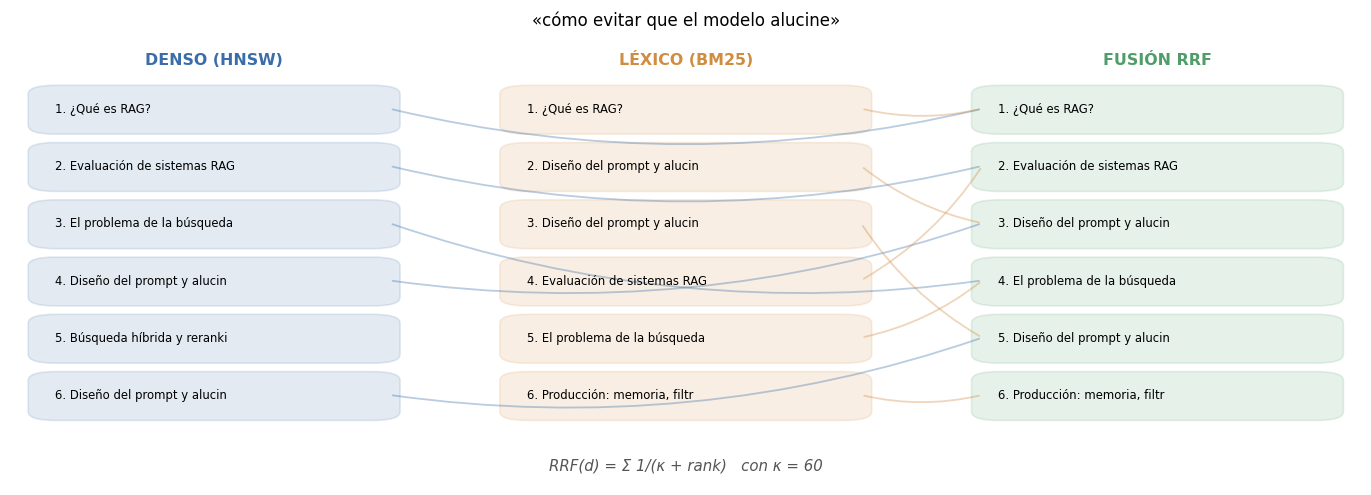

In [ ]:
# 🖼️ Cómo RRF fusiona dos rankings
def diagrama_rrf(consulta="cómo evitar que el modelo alucine", n=6, kappa=60):
    d = buscar_denso(consulta, k=n); l = buscar_bm25(consulta, k=n); h = buscar_hibrido(consulta, k=n)
    fig, ax = plt.subplots(figsize=(11.5, 4.2)); ax.axis("off"); ax.grid(False)
    cols = [(0.02, d, "DENSO (HNSW)", PALETA[0]), (0.37, l, "LÉXICO (BM25)", PALETA[1]),
            (0.72, h, "FUSIÓN RRF", PALETA[2])]
    pos = {}
    for cx, lista, titulo, color in cols:
        ax.text(cx + 0.13, 0.95, titulo, fontsize=9.5, fontweight="bold", ha="center", color=color)
        for i, r in enumerate(lista):
            y = 0.85 - i * 0.13
            ax.add_patch(FancyBboxPatch((cx, y - 0.05), 0.26, 0.095,
                                        boxstyle="round,pad=0.008,rounding_size=0.02",
                                        fc=color, alpha=0.14, ec=color, lw=1.0))
            ax.text(cx + 0.012, y, f"{i+1}. {r.titulo[:26]}", fontsize=7, va="center")
            pos.setdefault(titulo, {})[r.chunk_id] = (cx, y)
    # líneas de trazabilidad hacia la fusión
    for origen, color in [("DENSO (HNSW)", PALETA[0]), ("LÉXICO (BM25)", PALETA[1])]:
        for cid, (x, y) in pos[origen].items():
            if cid in pos["FUSIÓN RRF"]:
                x2, y2 = pos["FUSIÓN RRF"][cid]
                ax.add_patch(FancyArrowPatch((x + 0.26, y), (x2, y2), arrowstyle="-",
                                             color=color, alpha=0.35, lw=1.1,
                                             connectionstyle="arc3,rad=0.12"))
    ax.text(0.5, 0.03, r"RRF(d) = Σ 1/(κ + rank)   con κ = 60", ha="center",
            fontsize=9, style="italic", color="#555")
    ax.set_title(f"«{consulta}»", fontsize=10, pad=10)
    plt.tight_layout(); plt.show()

diagrama_rrf()

### 6.3 Reranking con *cross-encoder*

El patrón industrial estándar es **recuperar mucho y barato → reordenar poco y caro**:

```
1 000 000 chunks ──HNSW(ms)──▶ 50 candidatos ──cross-encoder(~100 ms)──▶ 5 finales ──▶ LLM
```

El cross-encoder ve la consulta y el documento **en la misma pasada**, así que capta interacciones
que un bi-encoder no puede. Coste: hay que ejecutarlo una vez por candidato → sólo para ~50.

Si el modelo no está disponible (offline), usamos un *reranker* heurístico de solapamiento léxico
que ilustra la misma **posición arquitectónica** en el pipeline.

In [ ]:
class Reranker:
    def __init__(self, modelo="cross-encoder/ms-marco-MiniLM-L-6-v2"):
        self.tipo, self.modelo = "heuristico", None
        try:
            from sentence_transformers import CrossEncoder
            self.modelo, self.tipo = CrossEncoder(modelo), "cross-encoder"
        except Exception:
            print("  ⚠️  Cross-encoder no disponible → reranker heurístico (solapamiento léxico)")

    def puntuar(self, consulta, textos):
        if self.tipo == "cross-encoder":
            return np.asarray(self.modelo.predict([(consulta, t) for t in textos]), dtype=float)
        qt = set(tokenizar_bm25(consulta))
        out = []
        for t in textos:
            dt = set(tokenizar_bm25(t))
            jac = len(qt & dt) / max(len(qt | dt), 1)
            cob = len(qt & dt) / max(len(qt), 1)          # cobertura de la consulta
            out.append(0.35 * jac + 0.65 * cob)
        return np.asarray(out)

RERANKER = Reranker()

@traceable(name="6c-reranking", run_type="tool")
def recuperar_y_rerankear(consulta: str, k: int = 4, fetch_k: int = 12) -> List[Resultado]:
    candidatos = buscar_hibrido(consulta, k=min(fetch_k, len(CHUNKS)), fetch_k=fetch_k * 2)
    puntos = RERANKER.puntuar(consulta, [c.texto for c in candidatos])
    orden = np.argsort(-puntos)[:k]
    return [Resultado(candidatos[i].chunk_id, candidatos[i].texto, candidatos[i].titulo,
                      candidatos[i].seccion, candidatos[i].fuente, float(puntos[i]),
                      candidatos[i].indice) for i in orden]

c = "cómo consigo que el modelo no invente y cite sus fuentes"
print(f"❓ {c}\n")
print("Antes del reranking (fusión RRF):")
for i, r in enumerate(buscar_hibrido(c, k=5), 1): print(f"   {i}. {r.titulo}")
print("\nDespués del reranking:")
for i, r in enumerate(recuperar_y_rerankear(c, k=5), 1): print(f"   {i}. {r.titulo}  ({r.similitud:.3f})")

  ⚠️  Cross-encoder no disponible → reranker heurístico (solapamiento léxico)
❓ cómo consigo que el modelo no invente y cite sus fuentes

Antes del reranking (fusión RRF):
   1. ¿Qué es RAG?
   2. Observabilidad con LangSmith
   3. Diseño del prompt y alucinaciones
   4. Evaluación de sistemas RAG
   5. Embeddings densos

Después del reranking:
   1. Diseño del prompt y alucinaciones  (0.393)
   2. Embeddings densos  (0.378)
   3. Orquestación con LangGraph  (0.327)
   4. Diseño del prompt y alucinaciones  (0.318)
   5. ¿Qué es RAG?  (0.317)


---
# 7 · Capa de Generación — **OpenRouter**

> **Objetivo:** que el LLM responda **sólo** con la evidencia recuperada, **cite** sus fuentes y
> **admita** cuando no sabe.

### 7.1 Por qué OpenRouter

OpenRouter es una pasarela: **una sola clave y una sola API** (compatible con la de OpenAI) para
acceder a modelos de Anthropic, OpenAI, Google, Meta, Mistral, DeepSeek… Cambiar de modelo es
cambiar un string, lo cual es ideal para comparar proveedores en un mismo RAG.

```python
from openai import OpenAI
cliente = OpenAI(base_url="https://openrouter.ai/api/v1",
                 api_key=os.environ["OPENROUTER_API_KEY"])
```

### 7.2 Anatomía de un buen prompt RAG

1. **Rol + regla dura** → *"responde ÚNICAMENTE con el contexto"*.
2. **Contexto numerado** → `[1] [2] [3]…` para poder citar.
3. **Obligación de citar** → toda afirmación lleva su `[n]`.
4. **Salida de escape** → *"si no está en el contexto, di que no lo sabes"*.
5. **Orden del contexto** ← ojo con el efecto ***lost in the middle***: los modelos atienden mejor
   al principio y al final. Con pocos fragmentos, pon el mejor primero.

In [ ]:
PLANTILLA_SISTEMA = """Eres un asistente experto que responde EXCLUSIVAMENTE a partir del contexto proporcionado.

Reglas estrictas:
1. Usa únicamente la información de los fragmentos numerados del CONTEXTO.
2. Cita la fuente de cada afirmación con su número entre corchetes, por ejemplo [1] o [2][3].
3. Si el contexto no contiene la respuesta, di exactamente: "No encuentro esa información en los documentos disponibles." y no añadas nada más.
4. No inventes datos, cifras ni referencias que no aparezcan en el contexto.
5. Responde en español, de forma clara y concisa (máximo 6 frases)."""

def formatear_contexto(resultados: List[Resultado], max_car: int = 900) -> str:
    partes = []
    for i, r in enumerate(resultados, 1):
        partes.append(f"[{i}] (fuente: {r.fuente} · «{r.titulo}»)\n{r.texto[:max_car]}")
    return "\n\n".join(partes)

def construir_prompt(consulta: str, resultados: List[Resultado]) -> List[Dict[str, str]]:
    usuario = (f"CONTEXTO:\n{formatear_contexto(resultados)}\n\n"
               f"PREGUNTA: {consulta}\n\n"
               f"RESPUESTA (con citas [n]):")
    return [{"role": "system", "content": PLANTILLA_SISTEMA},
            {"role": "user",   "content": usuario}]

# Veamos el prompt exacto que se enviará
ejemplo = recuperar_y_rerankear("¿qué es el recall@k y por qué importa en ANN?", k=3)
p = construir_prompt("¿qué es el recall@k y por qué importa en ANN?", ejemplo)
print("═"*96); print("SYSTEM:"); print(p[0]["content"])
print("═"*96); print("USER:");   print(p[1]["content"][:1400], "\n…")
print("═"*96)
print(f"Tamaño aproximado del prompt: {sum(len(m['content']) for m in p)//4} tokens (regla de 4 car/token)")

════════════════════════════════════════════════════════════════════════════════════════════════
SYSTEM:
Eres un asistente experto que responde EXCLUSIVAMENTE a partir del contexto proporcionado.

Reglas estrictas:
1. Usa únicamente la información de los fragmentos numerados del CONTEXTO.
2. Cita la fuente de cada afirmación con su número entre corchetes, por ejemplo [1] o [2][3].
3. Si el contexto no contiene la respuesta, di exactamente: "No encuentro esa información en los documentos disponibles." y no añadas nada más.
4. No inventes datos, cifras ni referencias que no aparezcan en el contexto.
5. Responde en español, de forma clara y concisa (máximo 6 frases).
════════════════════════════════════════════════════════════════════════════════════════════════
USER:
CONTEXTO:
[1] (fuente: manual/ann.md · «El problema de la búsqueda exacta»)
Por eso se recurre a la búsqueda aproximada del vecino más cercano, conocida como ANN, que acepta un pequeño
 error en el resultado a cambio de una 

In [ ]:
@traceable(name="7-generacion", run_type="llm")
def generar(consulta: str, resultados: List[Resultado],
            modelo: str = None, temperatura: float = 0.1, max_tokens: int = 600) -> Dict[str, Any]:
    """Llama a OpenRouter. Si no hay clave, devuelve una respuesta extractiva de reserva."""
    modelo = modelo or MODELO_OPENROUTER
    mensajes = construir_prompt(consulta, resultados)

    if not os.environ.get("OPENROUTER_API_KEY"):
        cuerpo = " ".join(
            f"{r.texto.split('.')[0].strip()}. [{i}]" for i, r in enumerate(resultados[:3], 1))
        return {"respuesta": "⚠️ [MODO OFFLINE — respuesta extractiva, sin LLM]\n\n" + cuerpo,
                "modelo": "fallback-extractivo", "tokens": None, "citas": list(range(1, len(resultados[:3])+1))}

    try:
        from openai import OpenAI
        cliente = OpenAI(base_url="https://openrouter.ai/api/v1",
                         api_key=os.environ["OPENROUTER_API_KEY"])
        r = cliente.chat.completions.create(
            model=modelo, messages=mensajes,
            temperature=temperatura, max_tokens=max_tokens,
            extra_headers={"HTTP-Referer": "https://localhost/rag-educativo",
                           "X-Title": "RAG HNSW Educativo"},
        )
        texto = r.choices[0].message.content
        return {"respuesta": texto, "modelo": modelo,
                "tokens": getattr(r, "usage", None) and r.usage.total_tokens,
                "citas": sorted({int(x) for x in re.findall(r"\[(\d+)\]", texto)})}
    except Exception as e:
        return {"respuesta": f"⚠️ Error al llamar a OpenRouter: {type(e).__name__}: {e}",
                "modelo": modelo, "tokens": None, "citas": []}

@traceable(name="RAG-pipeline-lineal", run_type="chain")
def rag(consulta: str, k: int = 4) -> Dict[str, Any]:
    """Pipeline completo en versión lineal (la versión con grafo llega en la sección 8)."""
    t0 = time.perf_counter()
    docs = recuperar_y_rerankear(consulta, k=k)
    t_rec = time.perf_counter() - t0
    g = generar(consulta, docs)
    return {"consulta": consulta, "respuesta": g["respuesta"], "modelo": g["modelo"],
            "fuentes": [{"n": i, "titulo": d.titulo, "fuente": d.fuente, "chunk": d.chunk_id}
                        for i, d in enumerate(docs, 1)],
            "citas": g["citas"], "latencia_retrieval_ms": t_rec*1000,
            "latencia_total_ms": (time.perf_counter()-t0)*1000}

def imprimir_rag(res):
    print("═"*96)
    print(f"❓ {res['consulta']}")
    print("─"*96)
    print(textwrap.fill(res["respuesta"], 94))
    print("─"*96)
    print("📚 Fuentes recuperadas:")
    for f in res["fuentes"]:
        marca = "✓ citada" if f["n"] in res["citas"] else "  no citada"
        print(f"   [{f['n']}] {f['titulo']:<42} {f['fuente']:<26} {marca}")
    print(f"\n⏱️  retrieval {res['latencia_retrieval_ms']:.1f} ms  ·  "
          f"total {res['latencia_total_ms']:.1f} ms  ·  🤖 {res['modelo']}")
    print("═"*96)

imprimir_rag(rag("¿Qué diferencia hay entre ef_construction y ef_search?"))

════════════════════════════════════════════════════════════════════════════════════════════════
❓ ¿Qué diferencia hay entre ef_construction y ef_search?
────────────────────────────────────────────────────────────────────────────────────────────────
⚠️ [MODO OFFLINE — respuesta extractiva, sin LLM]  Valores  altos, entre 100 y 500, producen
un grafo de mejor calidad a costa de un tiempo de construcción mayor; no  afecta a la memoria
final ni a la latencia de consulta. [1] El troceado por estructura  respeta títulos, párrafos
y listas del documento original y suele funcionar mejor en documentación técnica. [2] Un
sistema RAG se evalúa por partes porque los fallos tienen causas distintas. [3]
────────────────────────────────────────────────────────────────────────────────────────────────
📚 Fuentes recuperadas:
   [1] Parámetros de HNSW                         manual/hnsw_params.md      ✓ citada
   [2] Estrategias de chunking                    manual/chunking.md         ✓ citada
   [3] 

In [ ]:
# 🧪 Prueba de honestidad: pregunta cuya respuesta NO está en el corpus
imprimir_rag(rag("¿Cuál es la capital de Mongolia y cuántos habitantes tiene?"))

════════════════════════════════════════════════════════════════════════════════════════════════
❓ ¿Cuál es la capital de Mongolia y cuántos habitantes tiene?
────────────────────────────────────────────────────────────────────────────────────────────────
⚠️ [MODO OFFLINE — respuesta extractiva, sin LLM]  La búsqueda exacta del vecino más cercano
compara la consulta contra todos los vectores del corpus. [1] En la generación se miden la
fidelidad al contexto, la relevancia respecto a la pregunta y la completitud  frente a una
respuesta de referencia. [2] Al usar posiciones en vez de puntuaciones evita el problema de
tener que normalizar escalas  incomparables. [3]
────────────────────────────────────────────────────────────────────────────────────────────────
📚 Fuentes recuperadas:
   [1] El problema de la búsqueda exacta          manual/ann.md              ✓ citada
   [2] Evaluación de sistemas RAG                 manual/evaluacion.md       ✓ citada
   [3] Búsqueda híbrida y reranking 

---
# 8 · Capa de Orquestación — **LangGraph**

> **Objetivo:** dejar de encadenar funciones a mano y modelar el RAG como una **máquina de estados**
> con memoria, condiciones y **bucles**.

### 8.1 Los tres conceptos

| Concepto | Qué es |
|---|---|
| **Estado** | Un `TypedDict` compartido. Cada nodo recibe el estado y devuelve **sólo las claves que actualiza**. |
| **Nodo** | Una función `(estado) -> dict`. Aquí, cada capa del RAG es un nodo. |
| **Arista** | Conexión entre nodos. Las **condicionales** enrutan según el estado → permiten **ciclos**. |

### 8.2 Lo que vamos a construir: **RAG correctivo (CRAG)**

Un RAG lineal siempre responde, aunque haya recuperado basura. Con un grafo podemos añadir un
**control de calidad** y reintentar:

```
        ┌──────────────┐
        │  recuperar   │◀────────────┐
        └──────┬───────┘             │
               ▼                     │
        ┌──────────────┐             │
        │   evaluar    │             │
        └──────┬───────┘             │
       ¿suficiente?                  │
        ╱          ╲                 │
      sí            no ──▶ ┌──────────────────┐
       │                   │ reescribir query │
       ▼                   └──────────────────┘
  ┌──────────┐
  │  generar │      (+ contador de intentos: máx. 2 reintentos)
  └────┬─────┘
       ▼
      END
```

Las aristas condicionales son lo que separa una *cadena* de un *agente*.

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

class EstadoRAG(TypedDict, total=False):
    consulta_original: str      # lo que preguntó el usuario
    consulta_actual:   str      # puede haber sido reescrita
    documentos:        List[Any]
    calidad:           float
    suficiente:        bool
    intentos:          int
    respuesta:         str
    modelo:            str
    citas:             List[int]
    traza:             List[str]  # bitácora didáctica del recorrido

UMBRAL_CALIDAD = 0.28   # ajústalo según tu backend de embeddings
MAX_INTENTOS   = 2

In [ ]:
# ─────────────────────────── NODOS ───────────────────────────

def nodo_recuperar(estado: EstadoRAG) -> Dict[str, Any]:
    """Capas 3-6: embedding de la consulta, HNSW, fusión híbrida y reranking."""
    q = estado.get("consulta_actual") or estado["consulta_original"]
    docs = recuperar_y_rerankear(q, k=4, fetch_k=12)
    traza = estado.get("traza", []) + [f"🔍 recuperar('{q[:52]}…') → {len(docs)} docs"]
    return {"documentos": docs, "traza": traza, "intentos": estado.get("intentos", 0)}

def nodo_evaluar(estado: EstadoRAG) -> Dict[str, Any]:
    """Control de calidad: ¿la evidencia recuperada justifica responder?"""
    docs = estado.get("documentos", [])
    q = estado.get("consulta_actual") or estado["consulta_original"]
    if not docs:
        calidad = 0.0
    else:
        # similitud coseno real consulta↔documento (independiente del score del reranker)
        qv = EMB.codificar([q])[0]
        sims = VECTORES[[d.indice for d in docs]] @ qv
        calidad = float(0.7 * sims.max() + 0.3 * sims.mean())
    suf = calidad >= UMBRAL_CALIDAD
    traza = estado["traza"] + [f"⚖️ evaluar → calidad={calidad:.3f} "
                               f"({'SUFICIENTE ✅' if suf else 'INSUFICIENTE ❌'})"]
    return {"calidad": calidad, "suficiente": suf, "traza": traza}

def nodo_reescribir(estado: EstadoRAG) -> Dict[str, Any]:
    """Reformula la consulta para dar otra oportunidad al retriever."""
    q = estado.get("consulta_actual") or estado["consulta_original"]
    intentos = estado.get("intentos", 0) + 1

    if os.environ.get("OPENROUTER_API_KEY"):
        try:
            from openai import OpenAI
            cli = OpenAI(base_url="https://openrouter.ai/api/v1",
                         api_key=os.environ["OPENROUTER_API_KEY"])
            r = cli.chat.completions.create(
                model=MODELO_OPENROUTER, temperature=0.3, max_tokens=80,
                messages=[{"role": "system",
                           "content": "Reescribe la pregunta del usuario para mejorar la búsqueda "
                                      "documental: usa sinónimos y términos técnicos del dominio. "
                                      "Devuelve SOLO la nueva pregunta."},
                          {"role": "user", "content": q}])
            nueva = r.choices[0].message.content.strip()
        except Exception:
            nueva = q
    else:
        # Expansión heurística offline: añade términos del dominio
        sinonimos = {"rápido": "latencia rendimiento", "memoria": "RAM consumo bytes",
                     "trocear": "chunking fragmentos", "buscar": "recuperación retrieval kNN",
                     "grafo": "HNSW capas jerárquico", "inventar": "alucinación fidelidad groundedness"}
        extra = " ".join(v for k, v in sinonimos.items() if k in q.lower())
        nueva = f"{q} {extra}".strip()

    traza = estado["traza"] + [f"✏️ reescribir (intento {intentos}) → '{nueva[:60]}…'"]
    return {"consulta_actual": nueva, "intentos": intentos, "traza": traza}

def nodo_generar(estado: EstadoRAG) -> Dict[str, Any]:
    docs = estado.get("documentos", [])
    g = generar(estado["consulta_original"], docs)
    traza = estado["traza"] + [f"✍️ generar con {g['modelo']}"]
    return {"respuesta": g["respuesta"], "modelo": g["modelo"],
            "citas": g["citas"], "traza": traza}

def nodo_rendirse(estado: EstadoRAG) -> Dict[str, Any]:
    """Salida honesta cuando tras N intentos no hay evidencia suficiente."""
    traza = estado["traza"] + ["🛑 sin evidencia suficiente tras agotar los reintentos"]
    return {"respuesta": "No encuentro información suficiente en los documentos disponibles "
                         "para responder con fiabilidad a esa pregunta.",
            "modelo": "n/a", "citas": [], "traza": traza}

# ─────────────────────── ARISTA CONDICIONAL ───────────────────────

def decidir(estado: EstadoRAG) -> str:
    if estado.get("suficiente"):
        return "generar"
    if estado.get("intentos", 0) >= MAX_INTENTOS:
        return "rendirse"
    return "reescribir"

print("Nodos y router definidos ✅")

Nodos y router definidos ✅


In [ ]:
# ───────────────────── COMPILACIÓN DEL GRAFO ─────────────────────
grafo = StateGraph(EstadoRAG)

grafo.add_node("recuperar",  nodo_recuperar)
grafo.add_node("evaluar",    nodo_evaluar)
grafo.add_node("reescribir", nodo_reescribir)
grafo.add_node("generar",    nodo_generar)
grafo.add_node("rendirse",   nodo_rendirse)

grafo.add_edge(START, "recuperar")
grafo.add_edge("recuperar", "evaluar")
grafo.add_conditional_edges("evaluar", decidir,
                            {"generar": "generar", "reescribir": "reescribir", "rendirse": "rendirse"})
grafo.add_edge("reescribir", "recuperar")      # ← ¡el ciclo!
grafo.add_edge("generar",  END)
grafo.add_edge("rendirse", END)

APP = grafo.compile()
print("✅ Grafo compilado\n")

try:                                  # requiere `pip install grandalf`
    print(APP.get_graph().draw_ascii())
except Exception:
    print("(instala `grandalf` para el dibujo ASCII; mientras tanto, el Mermaid del grafo:)\n")
    print(APP.get_graph().draw_mermaid())

✅ Grafo compilado

                      +-----------+                          
                      | __start__ |                          
                      +-----------+                          
                             *                               
                             *                               
                             *                               
                      +-----------+                          
                      | recuperar |                          
                      +-----------+****                      
                      ***              ****                  
                     *                     ****              
                   **                          ****          
           +---------+                             **        
           | evaluar |....                          *        
           +---------+    .....                     *        
          ...         ..       .......             

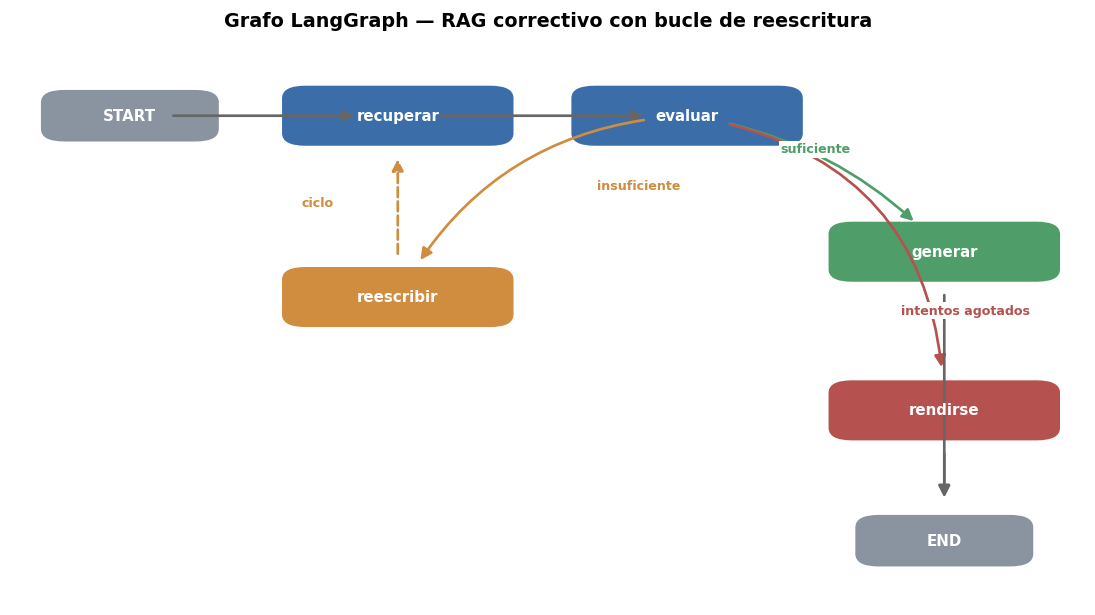

In [ ]:
# 🖼️ El mismo grafo, dibujado con matplotlib (no requiere red ni graphviz)
def diagrama_grafo():
    fig, ax = plt.subplots(figsize=(9.2, 5.2)); ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.axis("off"); ax.grid(False)
    nodos = {
        "START":      (1.1, 8.6, "#8A93A0"),
        "recuperar":  (3.6, 8.6, PALETA[0]),
        "evaluar":    (6.3, 8.6, PALETA[0]),
        "reescribir": (3.6, 5.4, PALETA[1]),
        "generar":    (8.7, 6.2, PALETA[2]),
        "rendirse":   (8.7, 3.4, PALETA[3]),
        "END":        (8.7, 1.1, "#8A93A0"),
    }
    for nombre, (x, y, c) in nodos.items():
        w, h = (1.5, 0.75) if nombre in ("START", "END") else (2.0, 0.9)
        ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle="round,pad=0.08,rounding_size=0.22", fc=c, ec="none"))
        ax.text(x, y, nombre, ha="center", va="center", color="white",
                fontsize=9, fontweight="bold")

    def arco(a, b, rad=0.0, color="#666", etiqueta="", ls="-", dx=0.0, dy=0.0):
        x1, y1, _ = nodos[a]; x2, y2, _ = nodos[b]
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=14,
                                     lw=1.6, color=color, ls=ls, shrinkA=26, shrinkB=26,
                                     connectionstyle=f"arc3,rad={rad}"))
        if etiqueta:
            ax.text((x1+x2)/2 + dx, (y1+y2)/2 + dy, etiqueta, fontsize=7.6,
                    color=color, ha="center", fontweight="bold",
                    bbox=dict(fc="white", ec="none", pad=1.2))

    arco("START", "recuperar")
    arco("recuperar", "evaluar")
    arco("evaluar", "generar",   rad=-0.18, color=PALETA[2], etiqueta="suficiente", dy=0.55)
    arco("evaluar", "reescribir", rad=0.28,  color=PALETA[1], etiqueta="insuficiente", dx=0.9, dy=0.3)
    arco("evaluar", "rendirse",  rad=-0.42, color=PALETA[3], etiqueta="intentos agotados", dx=1.4, dy=-0.9)
    arco("reescribir", "recuperar", rad=0.0, color=PALETA[1], ls="--", etiqueta="ciclo", dx=-0.75)
    arco("generar", "END", color="#666")
    arco("rendirse", "END", color="#666")

    ax.set_title("Grafo LangGraph — RAG correctivo con bucle de reescritura",
                 fontsize=11.5, fontweight="bold")
    plt.tight_layout(); plt.show()

diagrama_grafo()

In [ ]:
@traceable(name="RAG-grafo-langgraph", run_type="chain")
def rag_grafo(pregunta: str) -> EstadoRAG:
    return APP.invoke({"consulta_original": pregunta, "consulta_actual": pregunta,
                       "intentos": 0, "traza": []})

def imprimir_estado(e):
    print("═"*96)
    print(f"❓ {e['consulta_original']}")
    print("─"*96)
    print("🧭 Recorrido por el grafo:")
    for paso in e["traza"]:
        print("   " + paso)
    print("─"*96)
    print(textwrap.fill(e.get("respuesta", ""), 94))
    if e.get("documentos"):
        print("─"*96); print("📚 Fuentes:")
        for i, d in enumerate(e["documentos"], 1):
            print(f"   [{i}] {d.titulo}  ·  {d.fuente}")
    print("═"*96, "\n")

# Caso A: la primera recuperación ya es buena → camino directo
imprimir_estado(rag_grafo("¿Cómo funciona la búsqueda por capas en HNSW?"))

# Caso B: pregunta vaga → debería activar el bucle de reescritura
imprimir_estado(rag_grafo("¿cómo lo hago más rápido sin gastar tanta memoria?"))

# Caso C: fuera de dominio → debería acabar en 'rendirse'
imprimir_estado(rag_grafo("¿Cuál fue el resultado de la final del Mundial de 1986?"))

════════════════════════════════════════════════════════════════════════════════════════════════
❓ ¿Cómo funciona la búsqueda por capas en HNSW?
────────────────────────────────────────────────────────────────────────────────────────────────
🧭 Recorrido por el grafo:
   🔍 recuperar('¿Cómo funciona la búsqueda por capas en HNSW?…') → 4 docs
   ⚖️ evaluar → calidad=0.645 (SUFICIENTE ✅)
   ✍️ generar con fallback-extractivo
────────────────────────────────────────────────────────────────────────────────────────────────
⚠️ [MODO OFFLINE — respuesta extractiva, sin LLM]  HNSW son las siglas de Hierarchical
Navigable Small World, un índice aproximado propuesto por Malkov y  Yashunin en 2016 que hoy
es el estándar de facto en bases de datos vectoriales como Qdrant, Weaviate,  Milvus,
Elasticsearch y pgvector. [1] Por eso se recurre a la búsqueda aproximada del vecino más
cercano, conocida como ANN, que acepta un pequeño  error en el resultado a cambio de una
aceleración de dos o tres órdenes 

### 8.3 *Streaming* de estados: ver el grafo pensar

`APP.stream()` emite el estado tras **cada nodo**. Es la forma natural de alimentar una interfaz
con mensajes tipo *"Buscando…"*, *"Reformulando la consulta…"*, *"Redactando…"*.

In [ ]:
print("Ejecución paso a paso:\n")
for i, evento in enumerate(APP.stream({"consulta_original": "cuánta RAM necesito para un millón de vectores",
                                       "consulta_actual": "cuánta RAM necesito para un millón de vectores",
                                       "intentos": 0, "traza": []}), 1):
    for nodo, delta in evento.items():
        claves = [k for k in delta if k != "traza"]
        print(f"  paso {i} · nodo '{nodo}' → actualiza {claves}")
        if "calidad" in delta:
            print(f"           calidad = {delta['calidad']:.3f}")
        if "respuesta" in delta:
            print(f"           respuesta = «{delta['respuesta'][:80]}…»")

Ejecución paso a paso:

  paso 1 · nodo 'recuperar' → actualiza ['documentos', 'intentos']
  paso 2 · nodo 'evaluar' → actualiza ['calidad', 'suficiente']
           calidad = 0.747
  paso 3 · nodo 'generar' → actualiza ['respuesta', 'modelo', 'citas']
           respuesta = «⚠️ [MODO OFFLINE — respuesta extractiva, sin LLM]

En producción conviene estima…»


---
# 9 · Capa de Observabilidad — **LangSmith**

> **Objetivo:** dejar de depurar con `print()` y ver **la traza completa** de cada consulta: qué
> recuperó cada capa, cuánto tardó, cuántos tokens costó y por qué el grafo tomó cada decisión.

### 9.1 Qué es una traza

```
RAG-grafo-langgraph                       1 840 ms   ← run raíz
├── recuperar                               210 ms
│   ├── 6b-fusion-rrf                        180 ms
│   │   ├── 5-retrieval-denso                 12 ms   inputs/outputs visibles
│   │   └── 6a-retrieval-bm25                  4 ms
│   └── 6c-reranking                          28 ms
├── evaluar                                    9 ms   calidad = 0.41
└── 7-generacion                            1 620 ms  1 284 tokens · $0.0021
```

Cada función decorada con `@traceable` es un **span**; el anidamiento se deduce solo de las
llamadas. Los nodos de LangGraph aparecen automáticamente, sin decorar nada.

### 9.2 Los `run_type` importan

`"retriever"`, `"llm"`, `"chain"`, `"tool"`, `"prompt"` — LangSmith usa el tipo para renderizar la
interfaz: los `retriever` muestran los documentos recuperados con su score, los `llm` muestran los
mensajes y el consumo de tokens. Por eso los hemos anotado en cada capa.

### 9.3 Metadatos y etiquetas: la clave para comparar experimentos

In [ ]:
from contextlib import contextmanager

try:
    from langsmith import tracing_context
except Exception:
    tracing_context = None

@contextmanager
def experimento(nombre: str, **metadatos):
    """Etiqueta todas las trazas generadas dentro del bloque (p. ej. una configuración concreta)."""
    if tracing_context and os.environ.get("LANGSMITH_TRACING") == "true":
        with tracing_context(tags=[nombre], metadata=metadatos):
            yield
    else:
        print(f"  (offline) experimento '{nombre}' con metadatos {metadatos}")
        yield

with experimento("config-M16-ef64", M=16, ef_search=64, k=4,
                 modelo=MODELO_OPENROUTER, backend_emb=EMB.tipo):
    resultado = rag_grafo("¿qué es la fusión recíproca de rangos?")

print("\nRespuesta:", textwrap.fill(resultado["respuesta"], 92)[:420], "…")

if HAY_LANGSMITH:
    print(f"\n🔗 Abre las trazas en: https://smith.langchain.com  ·  proyecto "
          f"'{os.environ.get('LANGSMITH_PROJECT')}'")
else:
    print("\nℹ️  Define LANGSMITH_API_KEY y reejecuta la sección 0.2 para ver las trazas reales.")

  (offline) experimento 'config-M16-ef64' con metadatos {'M': 16, 'ef_search': 64, 'k': 4, 'modelo': 'anthropic/claude-3.5-haiku', 'backend_emb': 'tfidf-svd'}

Respuesta: ⚠️ [MODO OFFLINE — respuesta extractiva, sin LLM]  La búsqueda densa entiende sinónimos y
paráfrasis, pero falla con términos raros, códigos de producto,  nombres propios y siglas
poco frecuentes. [1] Por eso se recurre a la búsqueda aproximada del vecino más cercano,
conocida como ANN, que acepta un pequeño  error en el resultado a cambio de una aceleración
de dos o tres órdenes de magnitud. [2] Al usar posiciones e …

ℹ️  Define LANGSMITH_API_KEY y reejecuta la sección 0.2 para ver las trazas reales.


### 9.4 Instrumentar bien un *retriever*

Para que LangSmith renderice la vista de documentos, la función marcada como `run_type="retriever"`
debe devolver una lista de objetos con **`page_content`** y **`metadata`**. Nuestros `Resultado`
usan otro esquema, así que añadimos un adaptador:

In [ ]:
try:
    from langchain_core.documents import Document
    _DOC_OK = True
except Exception:
    _DOC_OK = False

@traceable(name="retriever-formato-langsmith", run_type="retriever")
def buscar_para_langsmith(consulta: str, k: int = 4):
    """Devuelve Documents, que LangSmith renderiza en su vista especializada de retriever."""
    res = recuperar_y_rerankear(consulta, k=k)
    if not _DOC_OK:
        return [{"page_content": r.texto,
                 "metadata": {"score": r.similitud, "fuente": r.fuente, "titulo": r.titulo}}
                for r in res]
    return [Document(page_content=r.texto,
                     metadata={"score": round(r.similitud, 4), "fuente": r.fuente,
                               "titulo": r.titulo, "seccion": r.seccion,
                               "chunk_id": r.chunk_id})
            for r in res]

docs = buscar_para_langsmith("cómo se evalúa la fidelidad de una respuesta")
print(f"{len(docs)} documentos en formato LangSmith:\n")
for d in docs:
    meta = d.metadata if _DOC_OK else d["metadata"]
    cont = d.page_content if _DOC_OK else d["page_content"]
    print(f"  · {meta['titulo']:<40} score={meta['score']:.3f}")
    print(f"    {cont[:96]}…")

4 documentos en formato LangSmith:

  · Evaluación de sistemas RAG               score=0.608
    Un sistema RAG se evalúa por partes porque los fallos tienen causas distintas. En la recuperació…
  · Evaluación de sistemas RAG               score=0.535
    En la generación se miden la fidelidad al contexto, la relevancia respecto a la pregunta y la co…
  · Diseño del prompt y alucinaciones        score=0.528
    Tercero,
 vigilar el efecto de pérdida en el medio: los modelos atienden mejor al principio y al…
  · ¿Qué es RAG?                             score=0.515
    La Generación Aumentada por Recuperación (RAG, Retrieval-Augmented Generation) es una arquitectu…


---
# 10 · Capa de Evaluación

> **Objetivo:** sustituir *"parece que responde bien"* por **números reproducibles**.

### 10.1 Evalúa las capas por separado

Los fallos tienen causas distintas y el diagnóstico es mecánico:

| Síntoma | Causa probable | Dónde tocar |
|---|---|---|
| Recall bajo | chunking, modelo de embedding, `ef_search` bajo | capas 2-5 |
| Recall alto pero respuesta mala | prompt, modelo, orden del contexto | capa 7 |
| Respuesta correcta pero sin citas | prompt poco estricto | capa 7 |
| Recupera 5 párrafos idénticos | falta MMR | capa 5 |

### 10.2 Métricas de recuperación

* **Recall@k** — ¿aparece el documento relevante entre los k primeros? *(¿lo encontré?)*
* **MRR** — $\frac{1}{\text{rank del primer acierto}}$. *(¿lo puse arriba?)*
* **nDCG@k** — descuenta logarítmicamente por posición. *(¿el orden global es bueno?)*

In [ ]:
# Dataset dorado: pregunta → documento(s) que DEBERÍAN recuperarse
DATASET = [
 {"pregunta": "¿qué es RAG y qué ventajas aporta?",                      "docs": ["doc-01"]},
 {"pregunta": "¿por qué hay que normalizar los embeddings?",             "docs": ["doc-02"]},
 {"pregunta": "¿por qué la búsqueda exacta no escala?",                  "docs": ["doc-03"]},
 {"pregunta": "explica la estructura por capas del grafo HNSW",          "docs": ["doc-04"]},
 {"pregunta": "¿qué hace ef_construction frente a ef_search?",           "docs": ["doc-05"]},
 {"pregunta": "¿de qué tamaño deben ser los fragmentos de texto?",       "docs": ["doc-06"]},
 {"pregunta": "¿cómo combino BM25 con búsqueda vectorial?",              "docs": ["doc-07"]},
 {"pregunta": "¿cómo evito que el modelo alucine y cite fuentes?",       "docs": ["doc-08"]},
 {"pregunta": "¿qué métricas uso para evaluar la recuperación?",         "docs": ["doc-09"]},
 {"pregunta": "¿cómo veo las trazas de mi aplicación?",                  "docs": ["doc-10"]},
 {"pregunta": "¿cómo hago un bucle de reintento en el pipeline?",        "docs": ["doc-11"]},
 {"pregunta": "¿cuánta RAM necesito para un millón de vectores?",        "docs": ["doc-12"]},
]

def recall_at_k(rec, rel, k):  return len(set(rec[:k]) & set(rel)) / max(len(rel), 1)

def mrr(rec, rel):
    for i, d in enumerate(rec, 1):
        if d in rel: return 1.0 / i
    return 0.0

def ndcg_at_k(rec, rel, k):
    dcg = sum((1.0 / math.log2(i + 1)) for i, d in enumerate(rec[:k], 1) if d in rel)
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, min(len(rel), k) + 1))
    return dcg / idcg if idcg else 0.0

def evaluar_retriever(fn, nombre, k=5):
    R, M_, N_ = [], [], []
    for ej in DATASET:
        res = fn(ej["pregunta"], k=k)
        docs_rec = list(dict.fromkeys(r.chunk_id.split("::")[0] for r in res))   # dedup por doc
        R.append(recall_at_k(docs_rec, ej["docs"], k))
        M_.append(mrr(docs_rec, ej["docs"]))
        N_.append(ndcg_at_k(docs_rec, ej["docs"], k))
    return {"retriever": nombre, "recall@5": np.mean(R), "MRR": np.mean(M_), "nDCG@5": np.mean(N_)}

configs = [
    (lambda q, k=5: buscar_denso(q, k=k, ef=16),  "Denso (ef=16)"),
    (lambda q, k=5: buscar_denso(q, k=k, ef=128), "Denso (ef=128)"),
    (lambda q, k=5: buscar_bm25(q, k=k),          "BM25 léxico"),
    (lambda q, k=5: buscar_hibrido(q, k=k),       "Híbrido RRF"),
    (lambda q, k=5: mmr(q, k=k, lam=0.6),         "Denso + MMR"),
    (lambda q, k=5: recuperar_y_rerankear(q, k=k),"Híbrido + rerank"),
]
tabla = [evaluar_retriever(f, n) for f, n in configs]

print(f"{'retriever':<22}{'recall@5':>10}{'MRR':>8}{'nDCG@5':>9}")
print("─"*49)
for f in tabla:
    print(f"{f['retriever']:<22}{f['recall@5']:>10.3f}{f['MRR']:>8.3f}{f['nDCG@5']:>9.3f}")

retriever               recall@5     MRR   nDCG@5
─────────────────────────────────────────────────
Denso (ef=16)              0.917   0.660    0.724
Denso (ef=128)             0.917   0.660    0.724
BM25 léxico                0.833   0.653    0.699
Híbrido RRF                0.917   0.669    0.732
Denso + MMR                0.917   0.660    0.724
Híbrido + rerank           0.750   0.628    0.657


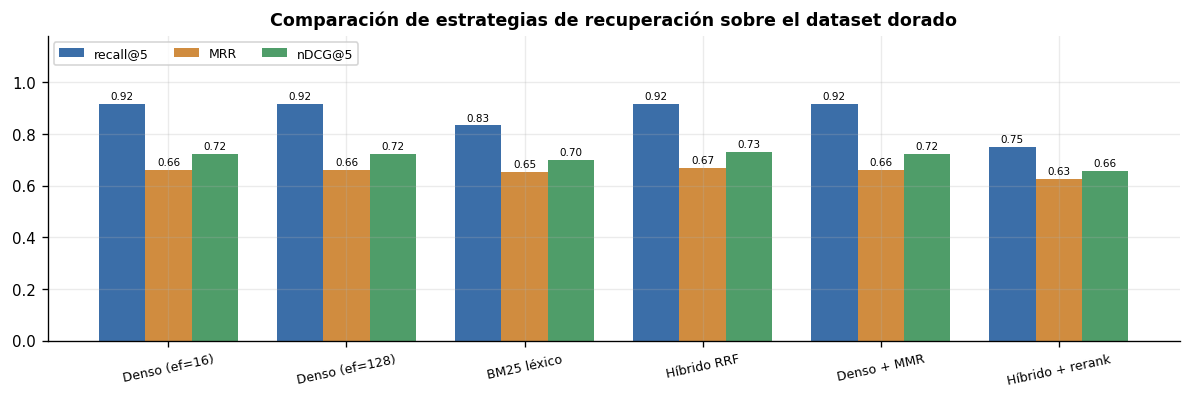

In [ ]:
# 📊 Comparativa visual de estrategias de recuperación
fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(tabla)); w = 0.26
for j, (m, c) in enumerate(zip(["recall@5", "MRR", "nDCG@5"], PALETA)):
    barras = ax.bar(x + (j-1)*w, [f[m] for f in tabla], w, label=m, color=c)
    ax.bar_label(barras, fmt="%.2f", fontsize=6.2, padding=1.5)
ax.set_xticks(x); ax.set_xticklabels([f["retriever"] for f in tabla], fontsize=7.6, rotation=12)
ax.set_ylim(0, 1.18); ax.legend(fontsize=7.5, ncol=3, loc="upper left")
ax.set_title("Comparación de estrategias de recuperación sobre el dataset dorado",
             fontsize=10.5, fontweight="bold")
plt.tight_layout(); plt.show()

### 10.3 Evaluación de la generación: *LLM-as-judge*

Para la respuesta no hay una métrica exacta, así que usamos **otro modelo como juez**. Las tres
dimensiones canónicas:

* **Fidelidad (*groundedness*)** — ¿cada afirmación se apoya en el contexto? ← *la más importante*
* **Relevancia** — ¿responde a lo que se preguntó?
* **Completitud** — ¿cubre lo esencial de la referencia?

Además añadimos un evaluador **determinista** de citas (rápido, gratis y sorprendentemente útil).

In [ ]:
@traceable(name="eval-citas", run_type="tool")
def evaluar_citas(respuesta: str, n_fuentes: int) -> Dict[str, Any]:
    """Evaluador determinista: ¿cita?, ¿las citas existen?"""
    citas = [int(x) for x in re.findall(r"\[(\d+)\]", respuesta)]
    validas = [c for c in citas if 1 <= c <= n_fuentes]
    rechazo = "no encuentro esa información" in respuesta.lower()
    return {"tiene_citas": len(citas) > 0,
            "citas_validas": len(validas) == len(citas) and len(citas) > 0,
            "n_citas": len(citas),
            "abstenida": rechazo,
            "puntuacion": 1.0 if (rechazo or (citas and len(validas) == len(citas))) else 0.0}

RUBRICA_JUEZ = """Eres un evaluador riguroso de sistemas RAG. Puntúa de 0 a 1 (un decimal).

fidelidad  : ¿TODA afirmación de la respuesta se apoya en el CONTEXTO? 1.0 = totalmente apoyada; 0.0 = inventa.
relevancia : ¿responde realmente a la PREGUNTA? 1.0 = directamente; 0.0 = no responde.
completitud: ¿cubre los puntos esenciales? 1.0 = completa; 0.0 = omite lo fundamental.

Si la respuesta admite honestamente no tener información y el contexto efectivamente no la contiene,
fidelidad = 1.0.

Devuelve SOLO un JSON: {"fidelidad":0.0,"relevancia":0.0,"completitud":0.0,"motivo":"<una frase>"}"""

@traceable(name="eval-llm-juez", run_type="llm")
def juez_llm(pregunta: str, respuesta: str, contexto: str, modelo=None) -> Dict[str, Any]:
    if not os.environ.get("OPENROUTER_API_KEY"):
        return {"fidelidad": None, "relevancia": None, "completitud": None,
                "motivo": "sin OPENROUTER_API_KEY — juez desactivado"}
    try:
        from openai import OpenAI
        cli = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"])
        r = cli.chat.completions.create(
            model=modelo or MODELO_OPENROUTER, temperature=0, max_tokens=250,
            messages=[{"role": "system", "content": RUBRICA_JUEZ},
                      {"role": "user", "content":
                       f"PREGUNTA:\n{pregunta}\n\nCONTEXTO:\n{contexto[:4000]}\n\nRESPUESTA:\n{respuesta}"}])
        txt = r.choices[0].message.content
        m = re.search(r"\{.*\}", txt, re.S)
        return json.loads(m.group()) if m else {"motivo": txt[:200]}
    except Exception as e:
        return {"fidelidad": None, "relevancia": None, "completitud": None,
                "motivo": f"error: {type(e).__name__}"}

# --- Ejecución de la evaluación end-to-end ---
print(f"{'pregunta':<44}{'citas':>7}{'fidel.':>8}{'relev.':>8}{'compl.':>8}")
print("─"*75)
filas_eval = []
for ej in DATASET[:6]:
    docs = recuperar_y_rerankear(ej["pregunta"], k=4)
    g = generar(ej["pregunta"], docs)
    ev_c = evaluar_citas(g["respuesta"], len(docs))
    ev_j = juez_llm(ej["pregunta"], g["respuesta"], formatear_contexto(docs))
    fmt = lambda v: f"{v:>8.2f}" if isinstance(v, (int, float)) else f"{'—':>8}"
    print(f"{ej['pregunta'][:42]:<44}{ev_c['puntuacion']:>7.1f}"
          f"{fmt(ev_j.get('fidelidad'))}{fmt(ev_j.get('relevancia'))}{fmt(ev_j.get('completitud'))}")
    filas_eval.append({**ev_c, **ev_j, "pregunta": ej["pregunta"]})
print("─"*75)
print(f"{'MEDIA citas':<44}{np.mean([f['puntuacion'] for f in filas_eval]):>7.2f}")
if not os.environ.get("OPENROUTER_API_KEY"):
    print("\nℹ️  Las columnas del juez requieren OPENROUTER_API_KEY.")

pregunta                                      citas  fidel.  relev.  compl.
───────────────────────────────────────────────────────────────────────────
¿qué es RAG y qué ventajas aporta?              1.0       —       —       —
¿por qué hay que normalizar los embeddings      1.0       —       —       —
¿por qué la búsqueda exacta no escala?          1.0       —       —       —
explica la estructura por capas del grafo       1.0       —       —       —
¿qué hace ef_construction frente a ef_sear      1.0       —       —       —
¿de qué tamaño deben ser los fragmentos de      1.0       —       —       —
───────────────────────────────────────────────────────────────────────────
MEDIA citas                                    1.00

ℹ️  Las columnas del juez requieren OPENROUTER_API_KEY.


### 10.4 Evaluación reproducible con `langsmith.evaluate`

El flujo profesional: **dataset versionado en LangSmith** + **evaluadores** + `evaluate()`.
Cada ejecución queda guardada como un *experimento* y puedes comparar versiones del RAG lado a lado
en la interfaz (recall de la v1 vs v2, coste, latencia p50/p95).

In [ ]:
NOMBRE_DATASET = "rag-hnsw-educativo-v1"

def subir_dataset_y_evaluar():
    """Crea el dataset en LangSmith (si no existe) y lanza un experimento."""
    cliente = LangSmithClient()

    # 1) Dataset ---------------------------------------------------------
    if cliente.has_dataset(dataset_name=NOMBRE_DATASET):
        ds = cliente.read_dataset(dataset_name=NOMBRE_DATASET)
        print(f"  Dataset existente: {NOMBRE_DATASET}")
    else:
        ds = cliente.create_dataset(NOMBRE_DATASET,
                                    description="Preguntas de control sobre RAG, HNSW y evaluación")
        cliente.create_examples(
            inputs=[{"pregunta": e["pregunta"]} for e in DATASET],
            outputs=[{"docs_relevantes": e["docs"]} for e in DATASET],
            dataset_id=ds.id)
        print(f"  ✅ Dataset creado con {len(DATASET)} ejemplos")

    # 2) Función a evaluar (la "target") ---------------------------------
    def objetivo(inputs: dict) -> dict:
        estado = rag_grafo(inputs["pregunta"])
        docs = list(dict.fromkeys(d.chunk_id.split("::")[0] for d in estado.get("documentos", [])))
        return {"respuesta": estado.get("respuesta", ""), "docs_recuperados": docs,
                "contexto": formatear_contexto(estado.get("documentos", []))}

    # 3) Evaluadores -----------------------------------------------------
    def ev_recall(outputs: dict, reference_outputs: dict) -> dict:
        rec, rel = outputs["docs_recuperados"], reference_outputs["docs_relevantes"]
        return {"key": "recall@5", "score": recall_at_k(rec, rel, 5)}

    def ev_mrr(outputs: dict, reference_outputs: dict) -> dict:
        return {"key": "mrr", "score": mrr(outputs["docs_recuperados"],
                                           reference_outputs["docs_relevantes"])}

    def ev_citas(outputs: dict) -> dict:
        return {"key": "citas_correctas",
                "score": evaluar_citas(outputs["respuesta"], 4)["puntuacion"]}

    def ev_fidelidad(inputs: dict, outputs: dict) -> dict:
        j = juez_llm(inputs["pregunta"], outputs["respuesta"], outputs["contexto"])
        s = j.get("fidelidad")
        return {"key": "fidelidad", "score": float(s) if isinstance(s, (int, float)) else None,
                "comment": j.get("motivo", "")}

    # 4) Experimento -----------------------------------------------------
    from langsmith import evaluate
    resultados = evaluate(
        objetivo, data=NOMBRE_DATASET,
        evaluators=[ev_recall, ev_mrr, ev_citas, ev_fidelidad],
        experiment_prefix="hnsw-M16-ef64-rrf-rerank",
        metadata={"M": 16, "ef_search": 64, "k": 4, "chunk": 120,
                  "backend_emb": EMB.tipo, "modelo": MODELO_OPENROUTER},
        max_concurrency=4)
    print("\n✅ Experimento lanzado. Compara versiones en https://smith.langchain.com")
    return resultados

if HAY_LANGSMITH:
    RESULTADOS_EVAL = subir_dataset_y_evaluar()
else:
    print("ℹ️  Sin LANGSMITH_API_KEY no se sube nada a la nube.")
    print("   El código de arriba es el patrón completo y reutilizable:")
    print("     1. create_dataset + create_examples")
    print("     2. función objetivo(inputs) -> outputs")
    print("     3. evaluadores (outputs, reference_outputs) -> {key, score}")
    print("     4. evaluate(objetivo, data=..., evaluators=[...], experiment_prefix=...)")

ℹ️  Sin LANGSMITH_API_KEY no se sube nada a la nube.
   El código de arriba es el patrón completo y reutilizable:
     1. create_dataset + create_examples
     2. función objetivo(inputs) -> outputs
     3. evaluadores (outputs, reference_outputs) -> {key, score}
     4. evaluate(objetivo, data=..., evaluators=[...], experiment_prefix=...)


### 10.5 Análisis de sensibilidad: ¿cuánto importa cada decisión de diseño?

Un experimento final que casi nadie hace y que ahorra muchísimo tiempo: **barrer el tamaño de chunk**
y medir el recall. Normalmente descubres que el chunking manda más que el modelo de embedding.

  chunk =  50 palabras  →  recall@5 = 0.833
  chunk =  80 palabras  →  recall@5 = 0.917


  chunk = 120 palabras  →  recall@5 = 0.917
  chunk = 180 palabras  →  recall@5 = 0.917


  chunk = 260 palabras  →  recall@5 = 0.917
  chunk = 400 palabras  →  recall@5 = 0.917


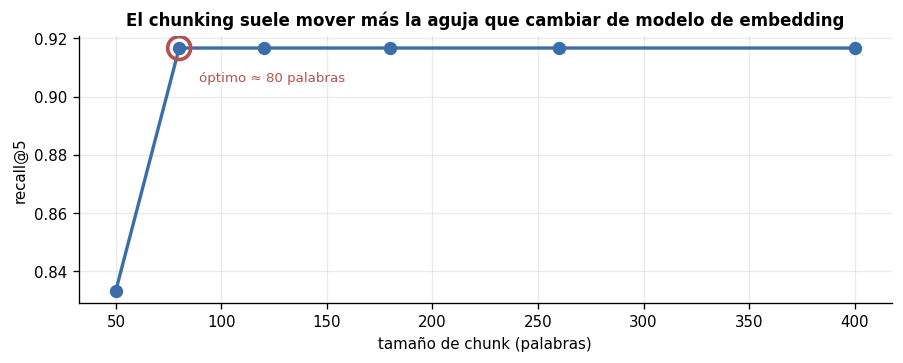

In [ ]:
def evaluar_tamano_chunk(tam: int, solape_frases: int = 1, k: int = 5) -> float:
    """Reconstruye chunks + embeddings + índice HNSW con otro tamaño y mide recall@k."""
    chunks = construir_chunks(DOCUMENTOS, tam=tam, solape_frases=solape_frases)
    emb = BackendEmbeddings(forzar_fallback=(EMB.tipo == "tfidf-svd"))
    emb.ajustar([c["texto_emb"] for c in chunks])
    V = emb.codificar([c["texto_emb"] for c in chunks])
    ix = hnswlib.Index(space="cosine", dim=V.shape[1])
    ix.init_index(max_elements=len(chunks), ef_construction=200, M=16, random_seed=42)
    ix.add_items(V, np.arange(len(chunks))); ix.set_ef(64)

    puntos = []
    for ej in DATASET:
        lab, _ = ix.knn_query(emb.codificar([ej["pregunta"]]), k=min(k, len(chunks)))
        docs = list(dict.fromkeys(chunks[int(i)]["doc_id"] for i in lab[0]))
        puntos.append(recall_at_k(docs, ej["docs"], k))
    return float(np.mean(puntos))

TAMANOS = [50, 80, 120, 180, 260, 400]
recalls_chunk = []
for t in TAMANOS:
    r_ = evaluar_tamano_chunk(t)
    recalls_chunk.append(r_)
    print(f"  chunk = {t:>3} palabras  →  recall@5 = {r_:.3f}")

fig, ax = plt.subplots(figsize=(7.6, 3.1))
ax.plot(TAMANOS, recalls_chunk, "o-", color=PALETA[0], lw=2, ms=7)
mejor_i = int(np.argmax(recalls_chunk))
ax.scatter([TAMANOS[mejor_i]], [recalls_chunk[mejor_i]], s=190, facecolor="none",
           edgecolor=PALETA[3], lw=2.2, zorder=5)
ax.annotate(f"óptimo ≈ {TAMANOS[mejor_i]} palabras", (TAMANOS[mejor_i], recalls_chunk[mejor_i]),
            xytext=(12, -20), textcoords="offset points", fontsize=8, color=PALETA[3])
ax.set_xlabel("tamaño de chunk (palabras)"); ax.set_ylabel("recall@5")
ax.set_title("El chunking suele mover más la aguja que cambiar de modelo de embedding",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

---
# 11 · Cierre

### 11.1 Resumen ejecutable del pipeline

```python
pregunta
  │
  ├─ 3  EMB.codificar(pregunta)              → vector normalizado (d dims)
  ├─ 5  INDICE.knn_query(v, k, ef_search)    → k candidatos en O(log n)
  ├─ 6  RRF(denso, bm25) → reranker          → k finales, precisos y diversos
  ├─ 8  evaluar calidad  → ¿reescribir?      → bucle correctivo (LangGraph)
  ├─ 7  generar con contexto numerado        → respuesta con citas (OpenRouter)
  └─ 9  cada paso, un span                   → traza completa (LangSmith)
```

### 11.2 Chuleta de HNSW

| Situación | Configuración recomendada |
|---|---|
| Prototipo, < 100 k vectores | `M=16`, `ef_construction=200`, `ef_search=64` |
| Producción, recall crítico | `M=32-64`, `ef_construction=400`, `ef_search=128-256` |
| Producción, latencia crítica | `M=16`, `ef_construction=200`, `ef_search=32-48` |
| RAM escasa | `M=8-12` + cuantización escalar int8 |

* Memoria ≈ $n\,(4d + 8M)$ bytes.
* **`ef_search` es lo único ajustable en caliente.** Empieza por ahí.
* HNSW **no borra de verdad**: reconstruye el índice periódicamente.
* **Siempre** valida el *recall* real contra fuerza bruta sobre una muestra antes de desplegar.

### 11.3 Los siete errores más comunes

1. Confundir **distancia** con **similitud** (`hnswlib` devuelve distancia → `sim = 1 - dist`).
2. **No normalizar** los vectores y usar el espacio `ip`.
3. Usar un modelo de embedding para indexar y **otro distinto** para consultar.
4. Chunks demasiado grandes → vectores diluidos.
5. **Post-filtrar** por metadatos en vez de filtrar durante el recorrido.
6. Meter 20 chunks en el prompt → *lost in the middle* y factura disparada.
7. **No medir**: ajustar el RAG a ojo en vez de con un dataset dorado.

### 11.4 Referencias

* Malkov & Yashunin (2016), *Efficient and robust approximate nearest neighbor search using
  Hierarchical Navigable Small World graphs* — arXiv:1603.09320
* Lewis et al. (2020), *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* — arXiv:2005.11401
* Cormack et al. (2009), *Reciprocal Rank Fusion outperforms Condorcet and individual Rank Learning Methods*
* Liu et al. (2023), *Lost in the Middle: How Language Models Use Long Contexts* — arXiv:2307.03172
* Documentación: [hnswlib](https://github.com/nmslib/hnswlib) ·
  [LangGraph](https://langchain-ai.github.io/langgraph/) ·
  [LangSmith](https://docs.smith.langchain.com/) ·
  [OpenRouter](https://openrouter.ai/docs)

---
*Cuaderno didáctico · RAG + HNSW + LangGraph + LangSmith + OpenRouter*